# Lab 12 - Apple Brand Monitor Visualization

This notebook implements the Lab 12 visualization assignment on the `social_media_brand_monitor` project using the Apple-focused cleaned dataset. Instead of movie analytics, every chart here answers a brand-monitoring question about Apple mentions across sources, time, languages, document types, and article-level quality proxies.

## Objectives

- demonstrate all static charts from `src/visualization/static_charts.py`
- demonstrate all interactive charts from `src/visualization/interactive_charts.py`
- run the automated visualization generator
- document why each chart type matches the data and question being asked
- keep the workflow reproducible from the cleaned Apple dataset

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.visualization import (
    generate_all_visualizations,
    interactive_mentions_timeline,
    interactive_multi_layout_dashboard,
    interactive_rating_by_document_type,
    interactive_title_length_scatter,
    interactive_top_sources,
    plot_dashboard_subplots,
    plot_language_year_heatmap,
    plot_mentions_and_rating_by_year,
    plot_mentions_by_document_type,
    plot_monthly_mentions_line,
    plot_rating_by_source_boxplot,
    plot_rating_distribution,
    plot_title_length_vs_rating,
    plot_top_sources_barh,
)

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned" / "cleaned_data.csv"
STATIC_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "visualizations" / "static"
INTERACTIVE_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "visualizations" / "interactive"

STATIC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
INTERACTIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")
df.head()

Project root: C:\Users\topic\OneDrive\Desktop\PROJECTS\Projekat za unstructured data\social_media_brand_monitor
Dataset path: C:\Users\topic\OneDrive\Desktop\PROJECTS\Projekat za unstructured data\social_media_brand_monitor\data\processed\cleaned\cleaned_data.csv
Dataset shape: (101, 20)


,_id,source,author,content,description,document_type,extraction_timestamp,publishedAt,title,url,urlToImage,date,type,language,rating,content_hash,record_date,overview,mention_date,mention_year
0,69ce9d979d3427d3654d3276,newsapi_Apple_page_2.json,Jusuf Hatic,Tim Cook hatte so einige Produkte in seiner Ze...,Nach über 15 Jahren hört Tim Cook als Apple-CE...,json,2026-04-25 20:39:13.673000+00:00,2026-04-24 19:59:00+00:00,News: Nach Rücktritt - »Mein erster großer Feh...,"https://www.gamestar.de/artikel/,3452032.html",https://images.cgames.de/images/gamestar/293/a...,NaN,Unknown,NaN,3.0,NaN,NaN,Nach über 15 Jahren hört Tim Cook als Apple-CE...,2026-04-24 00:00:00+00:00,2026
1,69ce9d979d3427d3654d3278,sample.csv,Alex Brown,Unknown,Unknown,csv,2026-04-25 20:39:14.090000+00:00,NaN,Apple doesnt lawsuit,NaN,NaN,2026-03-02 00:00:00+00:00,Unknown,NaN,3.0,NaN,NaN,Unknown,2026-03-02 00:00:00+00:00,2026
2,69ce9d979d3427d3654d3279,sample.xml,Alex Brown,Unknown,Unknown,xml,2026-04-25 20:39:14.100000+00:00,NaN,Apple faces lawsuit,NaN,NaN,2026-03-03 00:00:00+00:00,Unknown,NaN,3.0,NaN,NaN,Unknown,2026-03-03 00:00:00+00:00,2026
3,69ed2b5ef527cb7a1c1159e2,newsapi_Apple_page_1.json,Juli Clover,Apple is planning to start showing ads in the ...,Apple is planning to start showing ads in the ...,json,2026-04-25 21:11:28.488000+00:00,2026-04-24 20:58:00+00:00,Ads Are Coming to Apple Maps This Summer: Here...,https://www.macrumors.com/2026/04/24/apple-map...,https://images.macrumors.com/t/L7-hmAsT-RaznAY...,NaN,Unknown,NaN,3.0,NaN,NaN,Apple is planning to start showing ads in the ...,2026-04-24 00:00:00+00:00,2026
4,69ed2b5ef527cb7a1c1159eb,newsapi_Apple_page_1.json,sara.schwartz@expressen.se (Sara Schwartz Wiman),Den ideella föreningen Biosfärområde på Österl...,Techjätten Apple verkar inte vara så sugna på ...,json,2026-04-25 21:02:33.444000+00:00,2026-04-24 20:42:58+00:00,Apple ville sätta stopp för föreningslogga i Ö...,https://www.expressen.se/nyheter/sverige/apple...,https://static.bonniernews.se/images/27/8e/278...,NaN,Unknown,NaN,3.0,NaN,NaN,Techjätten Apple verkar inte vara så sugna på ...,2026-04-24 00:00:00+00:00,2026


## Dataset Context

The cleaned Apple dataset combines mentions extracted from several content sources and file types. The key fields used in this notebook are:

- `source`: where the mention came from
- `document_type`: json, csv, xml, and other source categories
- `language`: language indicator where available
- `rating`: a simple numeric score available in the cleaned dataset
- `title` and `overview`: text fields used to derive length-based metrics
- `mention_date` and `mention_year`: time fields used for trend analysis

In [2]:
df[[column for column in ["source", "document_type", "language", "rating", "mention_date", "mention_year"] if column in df.columns]].head(10)

,source,document_type,language,rating,mention_date,mention_year
0,newsapi_Apple_page_2.json,json,NaN,3.0,2026-04-24 00:00:00+00:00,2026
1,sample.csv,csv,NaN,3.0,2026-03-02 00:00:00+00:00,2026
2,sample.xml,xml,NaN,3.0,2026-03-03 00:00:00+00:00,2026
3,newsapi_Apple_page_1.json,json,NaN,3.0,2026-04-24 00:00:00+00:00,2026
4,newsapi_Apple_page_1.json,json,NaN,3.0,2026-04-24 00:00:00+00:00,2026
5,newsapi_Apple_page_1.json,json,NaN,3.0,2026-04-24 00:00:00+00:00,2026
6,newsapi_Apple_page_1.json,json,NaN,3.0,2026-04-24 00:00:00+00:00,2026
7,newsapi_Apple_page_1.json,json,NaN,3.0,2026-04-24 00:00:00+00:00,2026
8,newsapi_Apple_page_2.json,json,NaN,3.0,2026-04-24 00:00:00+00:00,2026
9,newsapi_Apple_page_2.json,json,NaN,3.0,2026-04-24 00:00:00+00:00,2026


## Static Charts

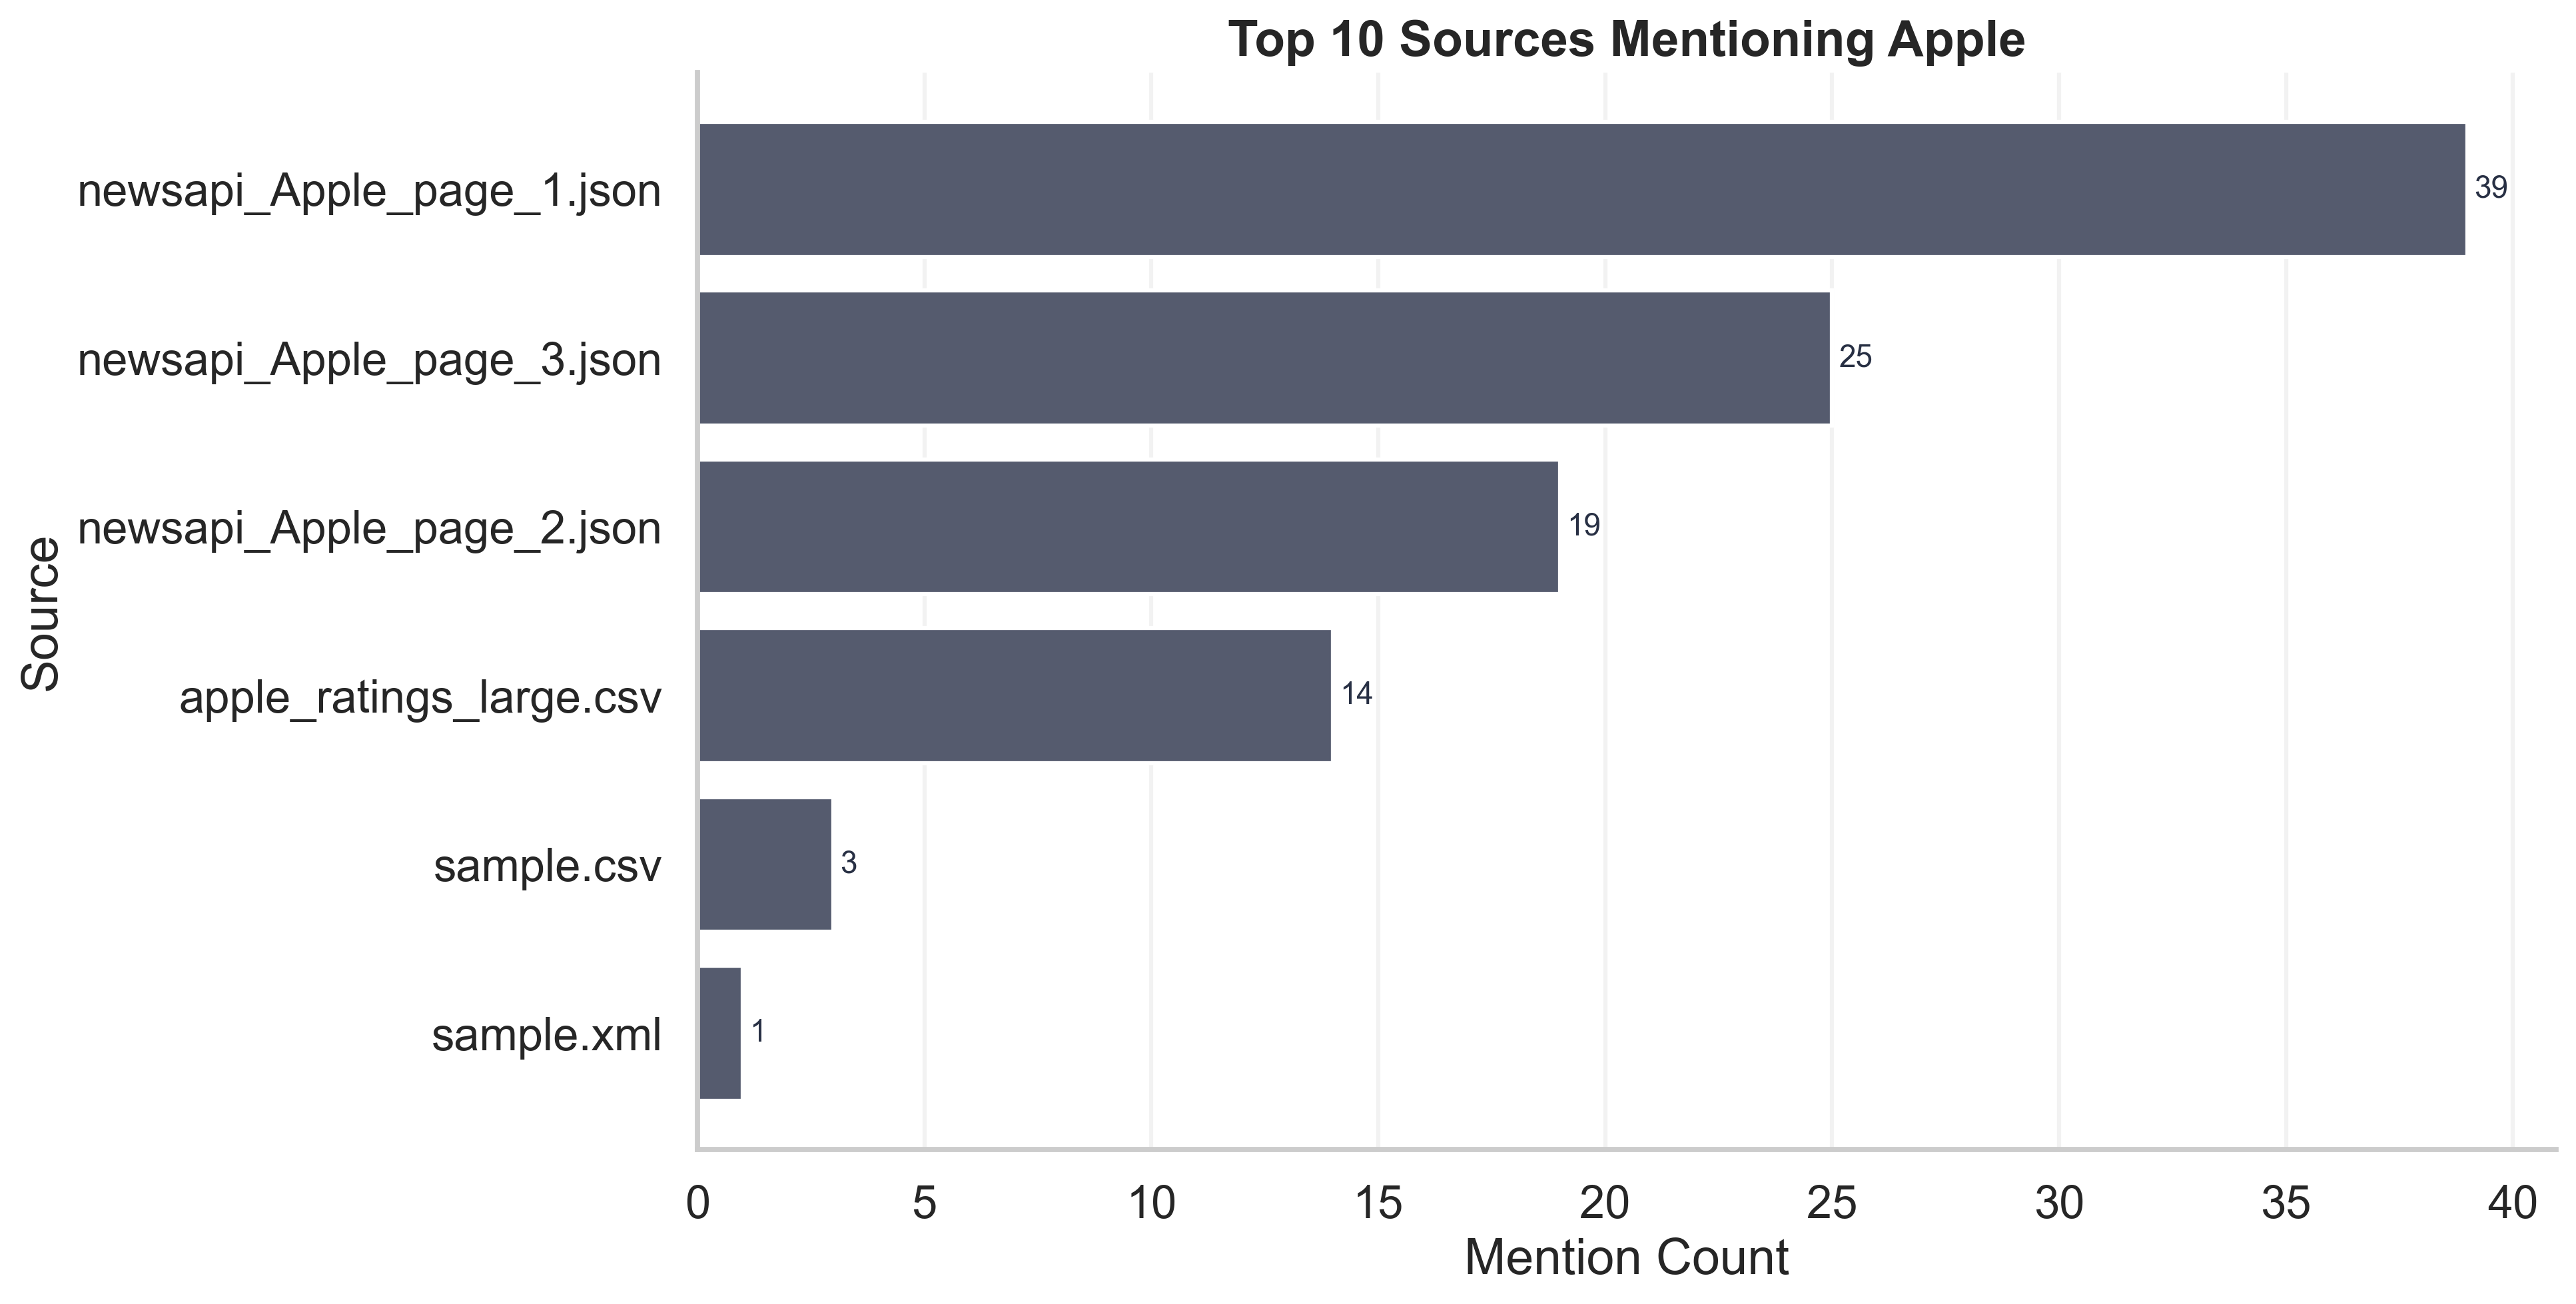

{'png': WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static/top_sources_barh.png'),
 'pdf': WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static/top_sources_barh.pdf')}

In [3]:
result = plot_top_sources_barh(df, STATIC_OUTPUT_DIR)
display(Image(filename=str(result["paths"]["png"])))
plt.close(result["figure"])
result["paths"]

### Explanation - Top Sources Horizontal Bar Chart

This chart shows which sources mention Apple most often in the cleaned dataset. A horizontal bar chart is the right choice because the categories are discrete and source names can be long. The left-to-right reading direction makes labels easier to scan than a vertical bar chart, and the direct count annotations reduce unnecessary eye movement, which supports Tufte's idea of maximizing useful ink.

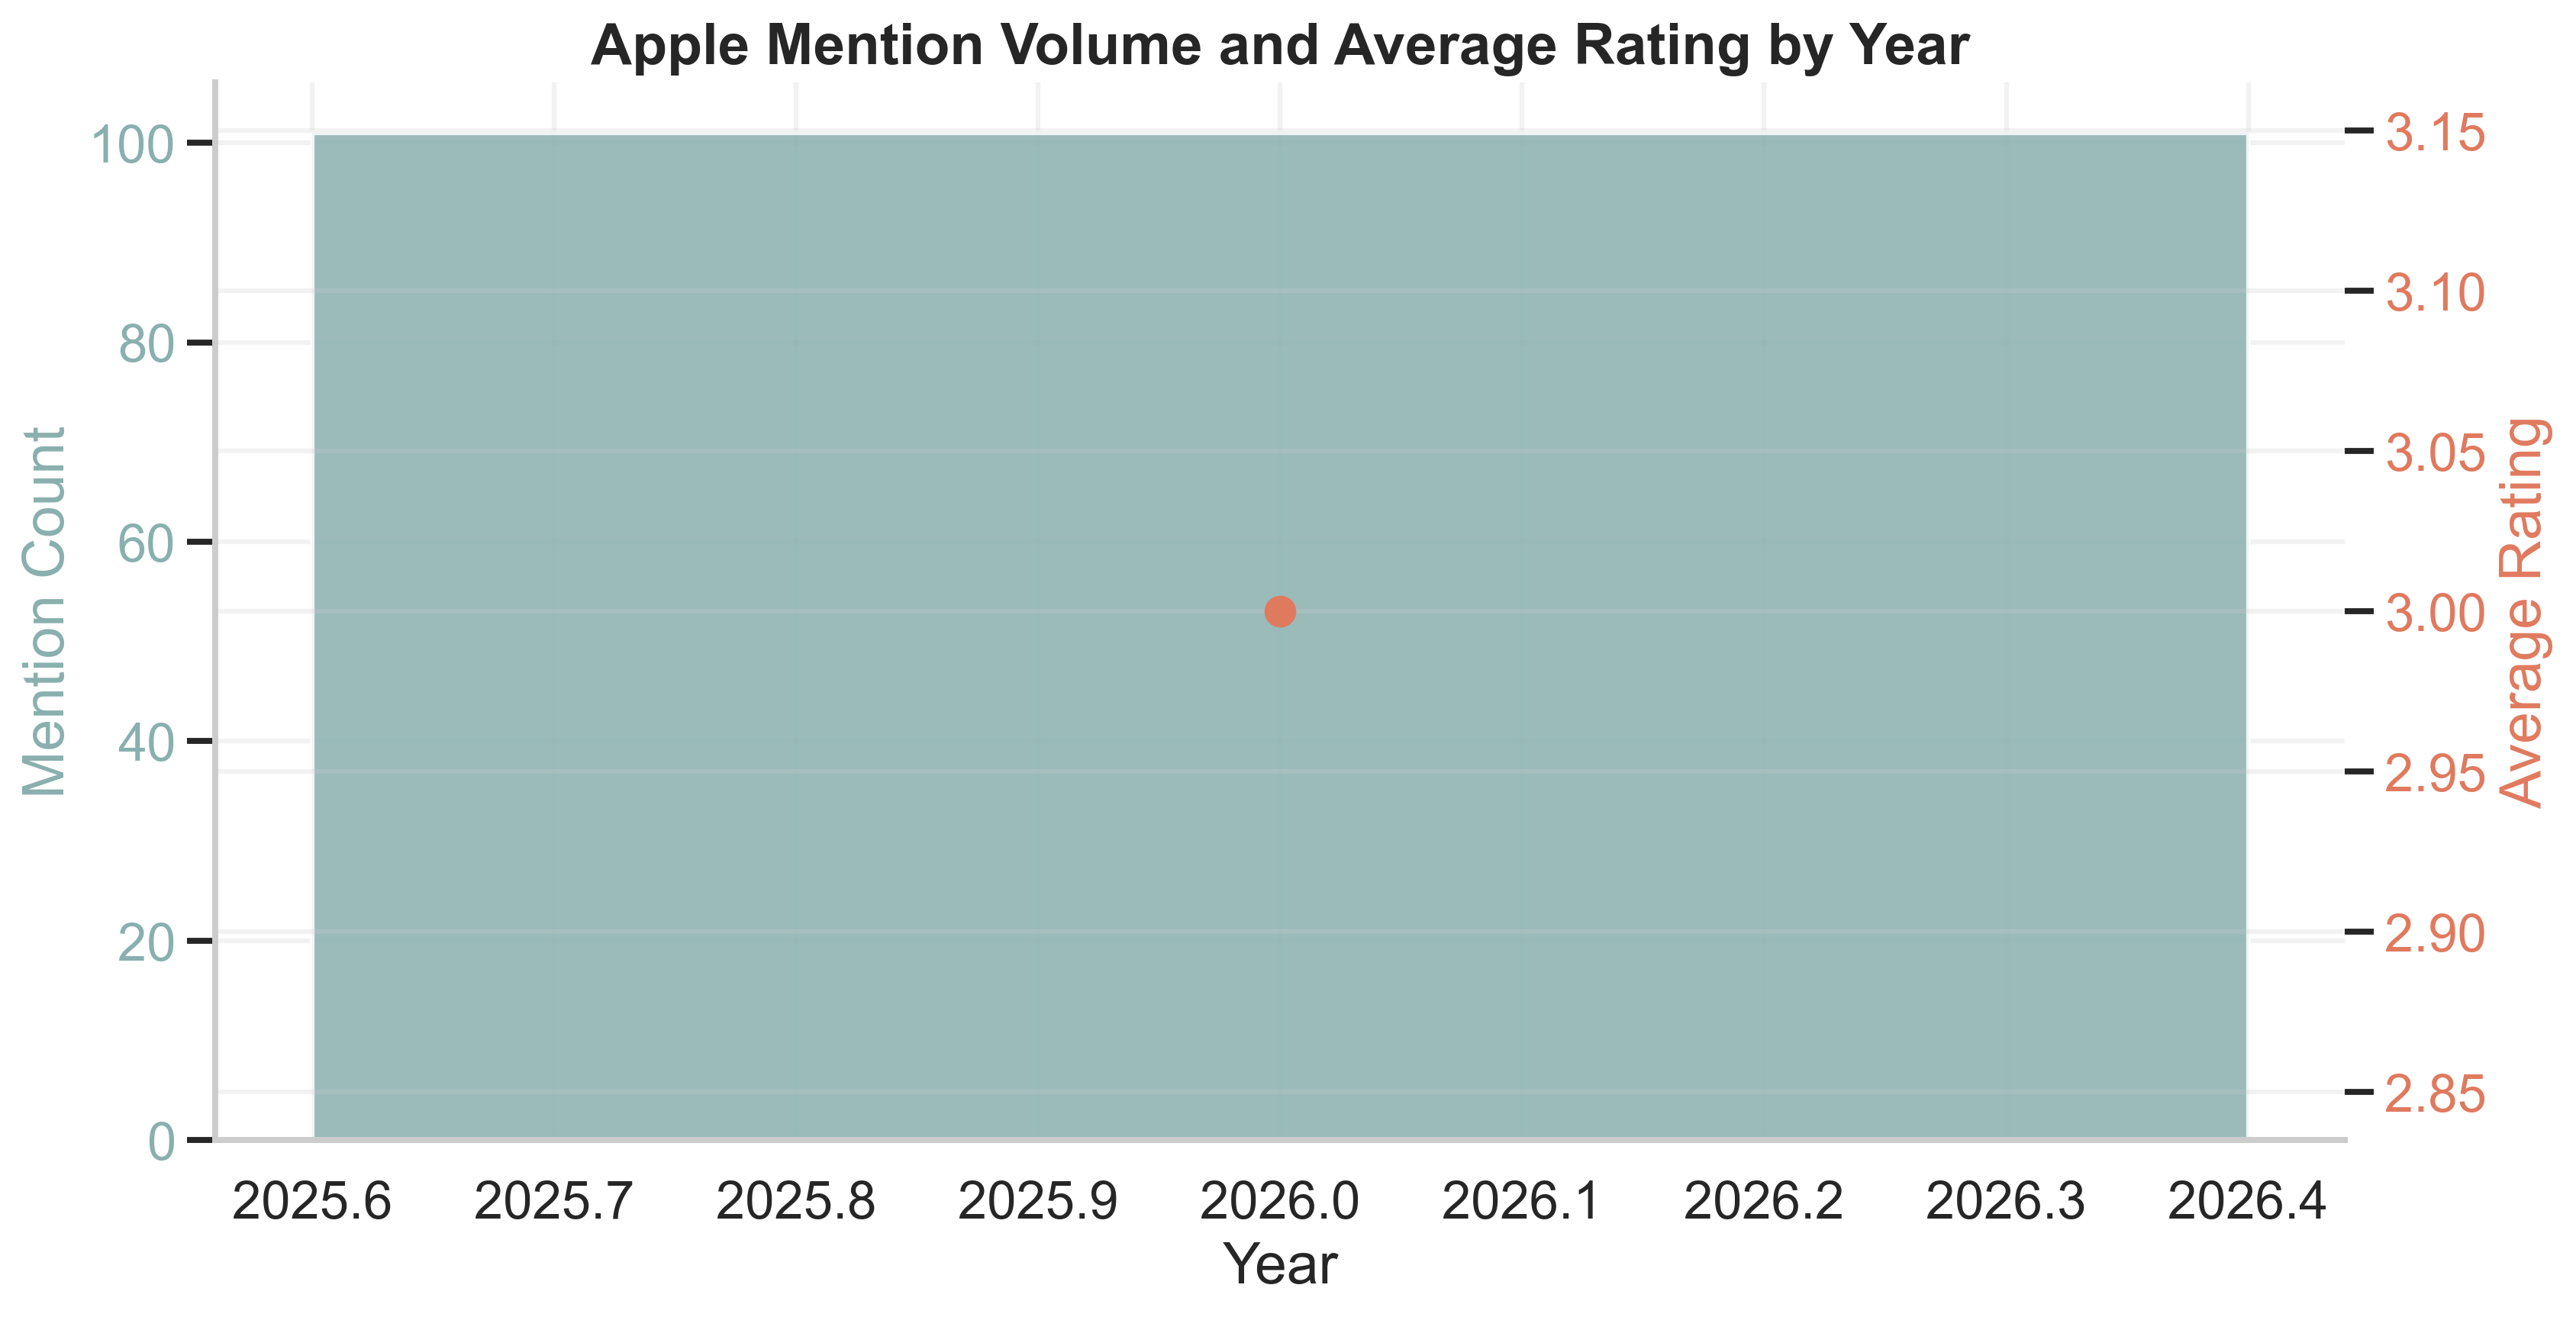

{'png': WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static/mentions_and_rating_by_year.png'),
 'pdf': WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static/mentions_and_rating_by_year.pdf')}

In [4]:
result = plot_mentions_and_rating_by_year(df, STATIC_OUTPUT_DIR)
display(Image(filename=str(result["paths"]["png"])))
plt.close(result["figure"])
result["paths"]

### Explanation - Mentions and Rating by Year

This chart compares two related yearly signals: how many Apple mentions were captured and how the average rating changed. A dual-axis design is appropriate here because both series share time on the x-axis but use different numeric scales. Bars encode yearly volume clearly, while the line emphasizes trend direction in the average rating without overwhelming the count signal.

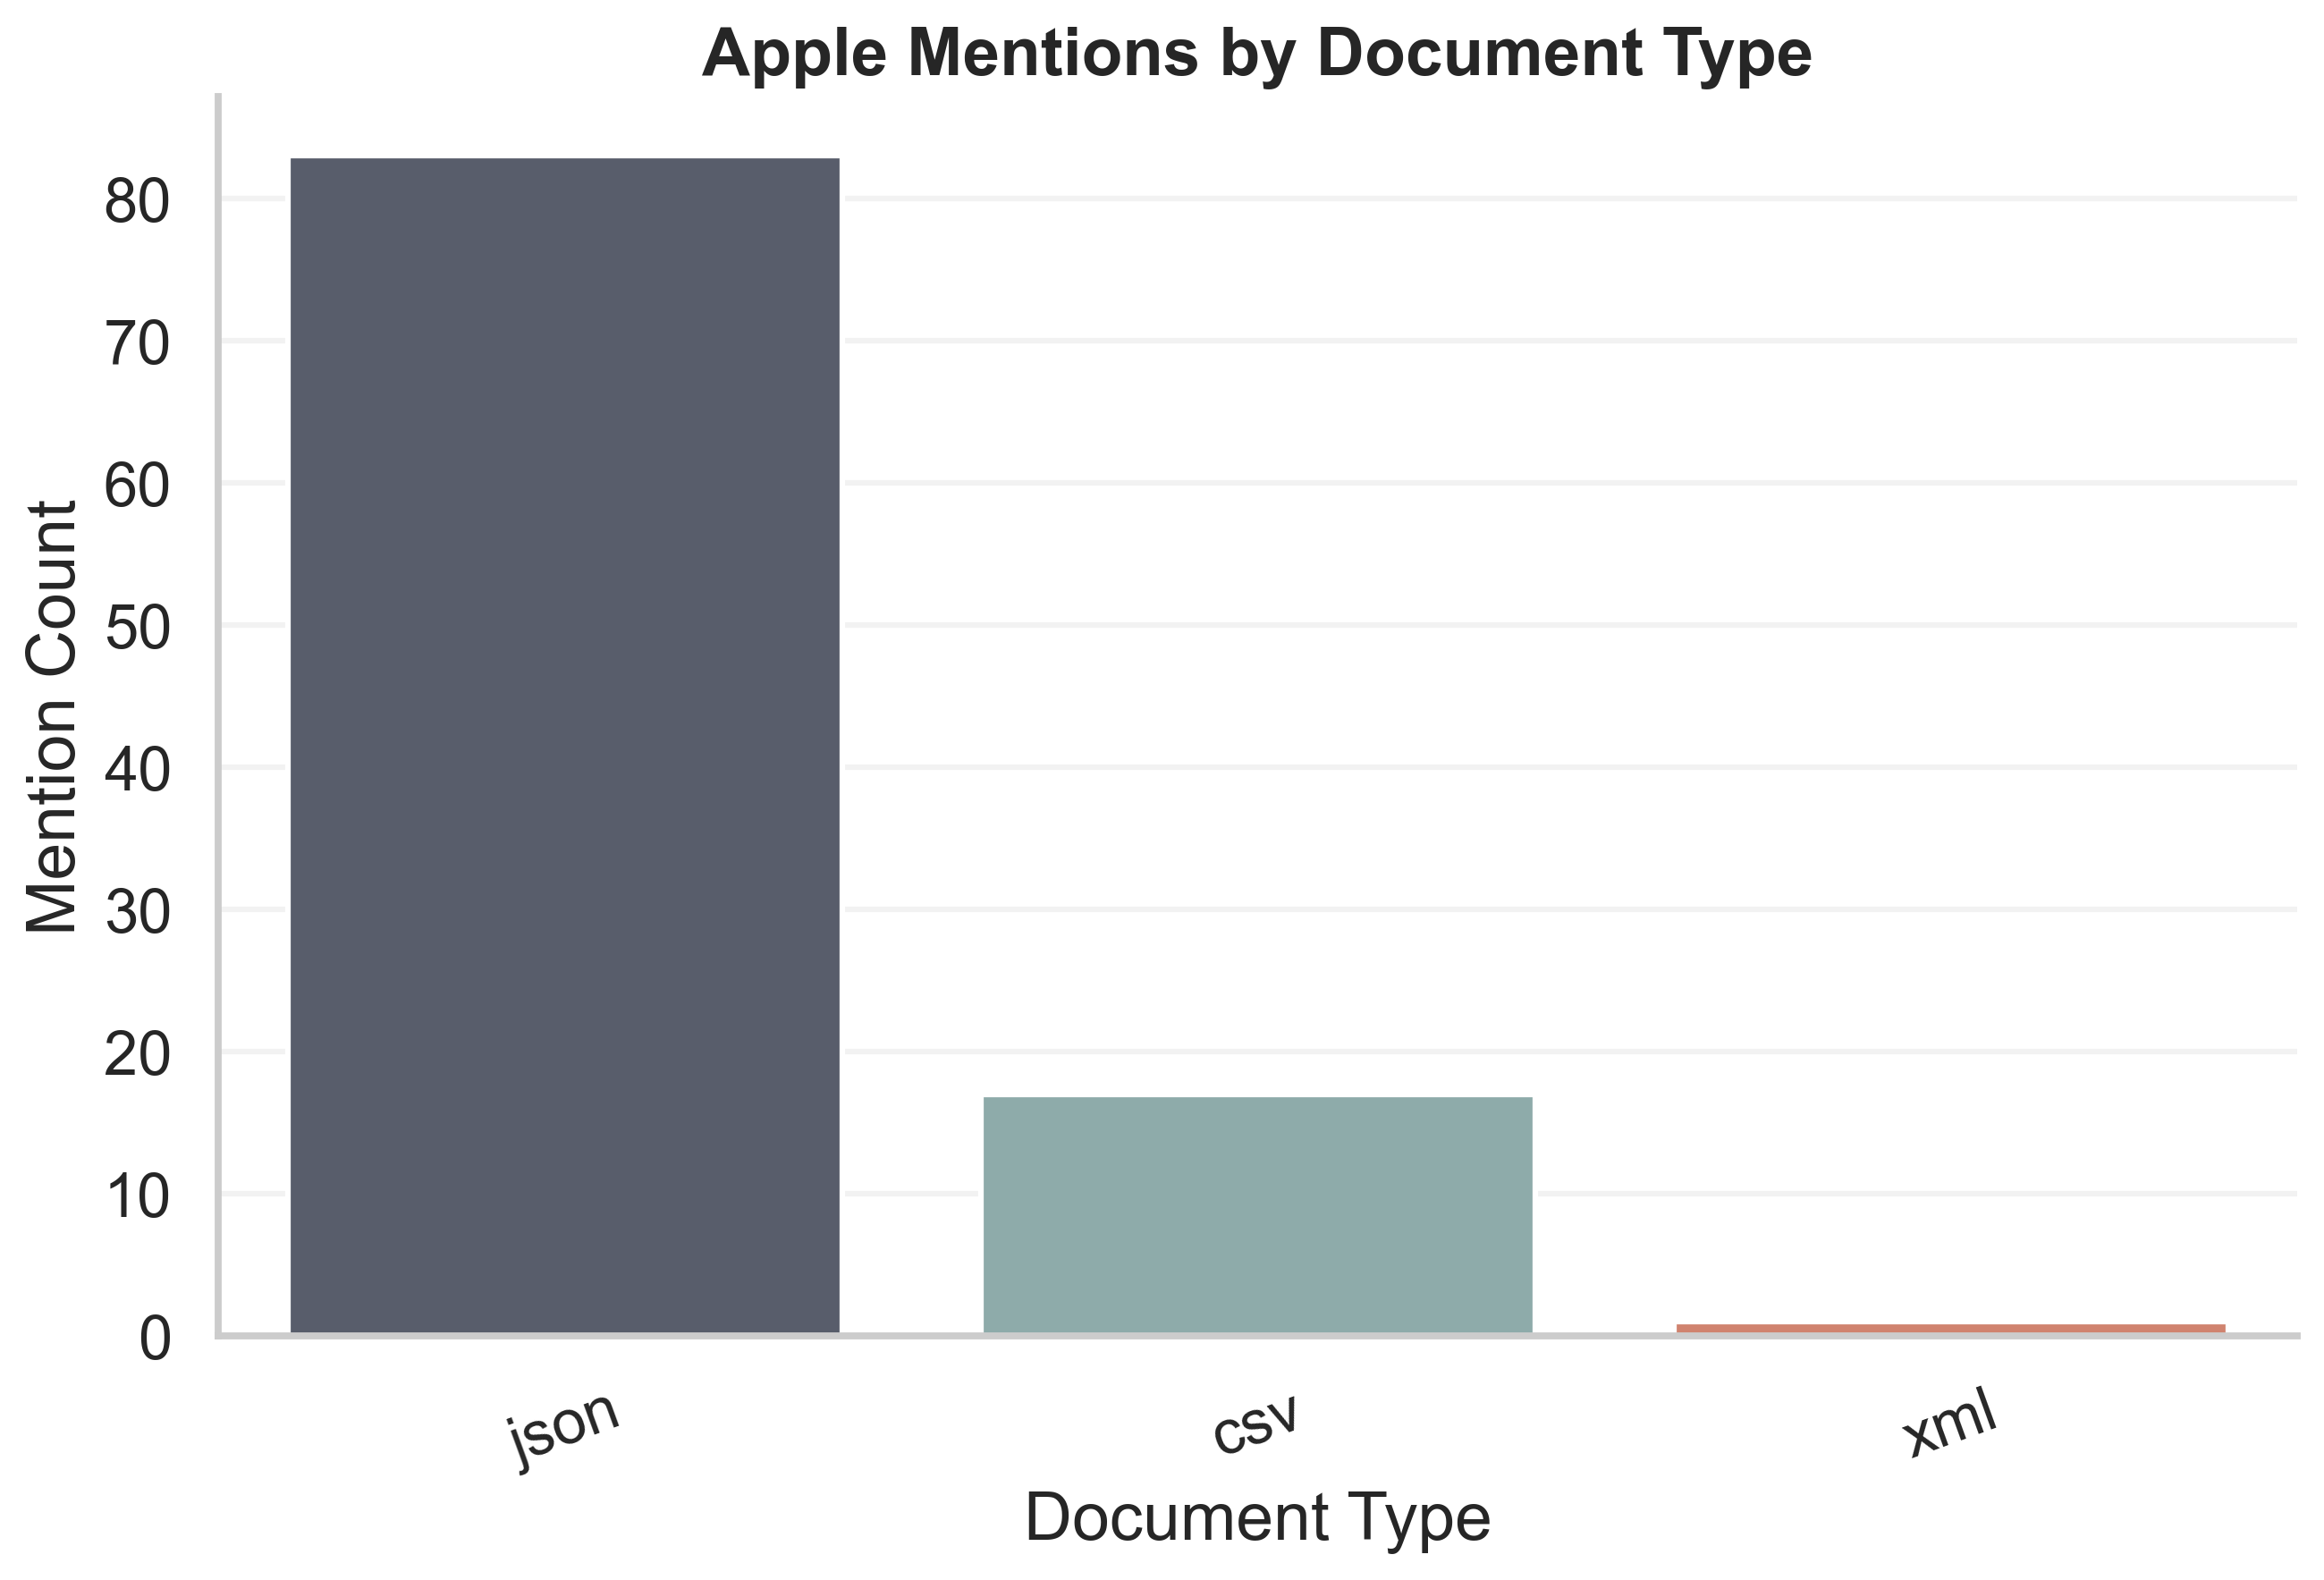

{'png': WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static/mentions_by_document_type.png'),
 'pdf': WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static/mentions_by_document_type.pdf')}

In [5]:
result = plot_mentions_by_document_type(df, STATIC_OUTPUT_DIR)
display(Image(filename=str(result["paths"]["png"])))
plt.close(result["figure"])
result["paths"]

### Explanation - Mentions by Document Type

This chart shows how the Apple mention dataset is distributed across document types. A bar chart is the most direct encoding for comparing discrete categories such as `json`, `csv`, or `xml`. The shared baseline makes it easy to judge relative frequency and quickly understand where most of the monitored content originates.

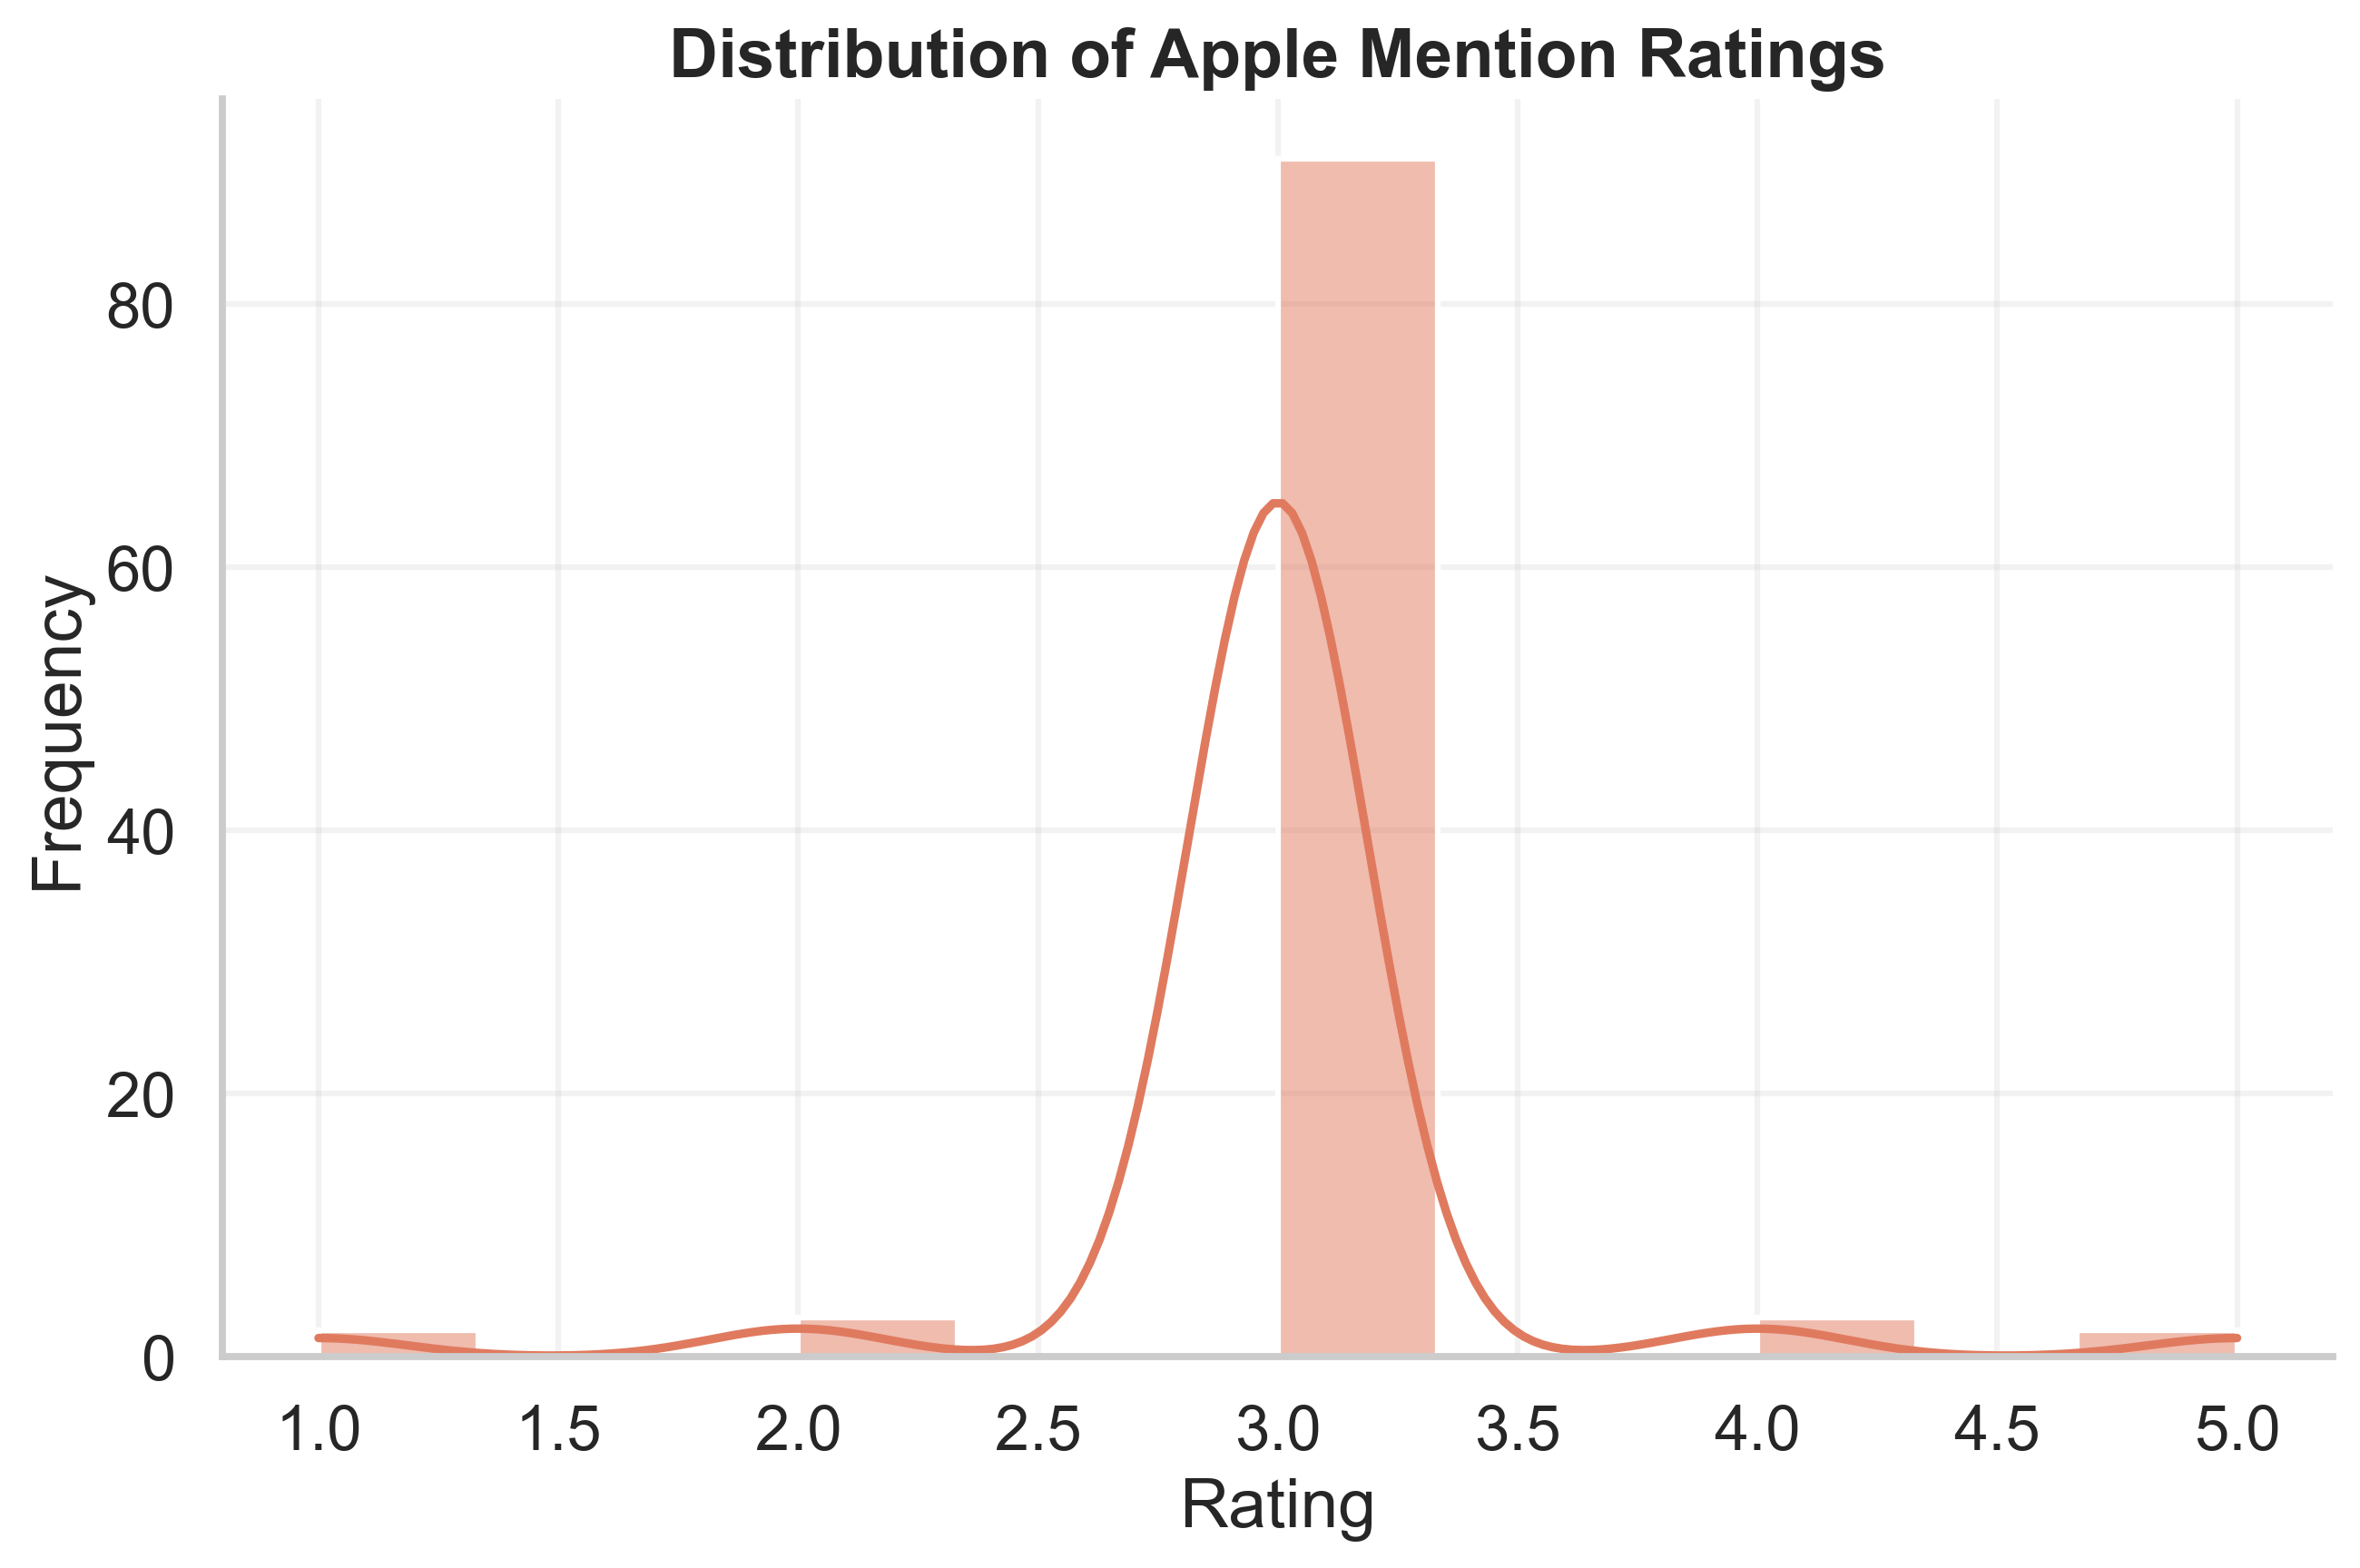

{'png': WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static/rating_distribution.png'),
 'pdf': WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static/rating_distribution.pdf')}

In [6]:
result = plot_rating_distribution(df, STATIC_OUTPUT_DIR)
display(Image(filename=str(result["paths"]["png"])))
plt.close(result["figure"])
result["paths"]

### Explanation - Rating Distribution Histogram

This figure shows how the numeric ratings are distributed across Apple mentions. A histogram is the correct chart type for studying the shape of one continuous variable because it reveals concentration, spread, and possible skew. The KDE overlay adds a smoothed density cue while keeping the main data-ink focused on the observed frequencies.

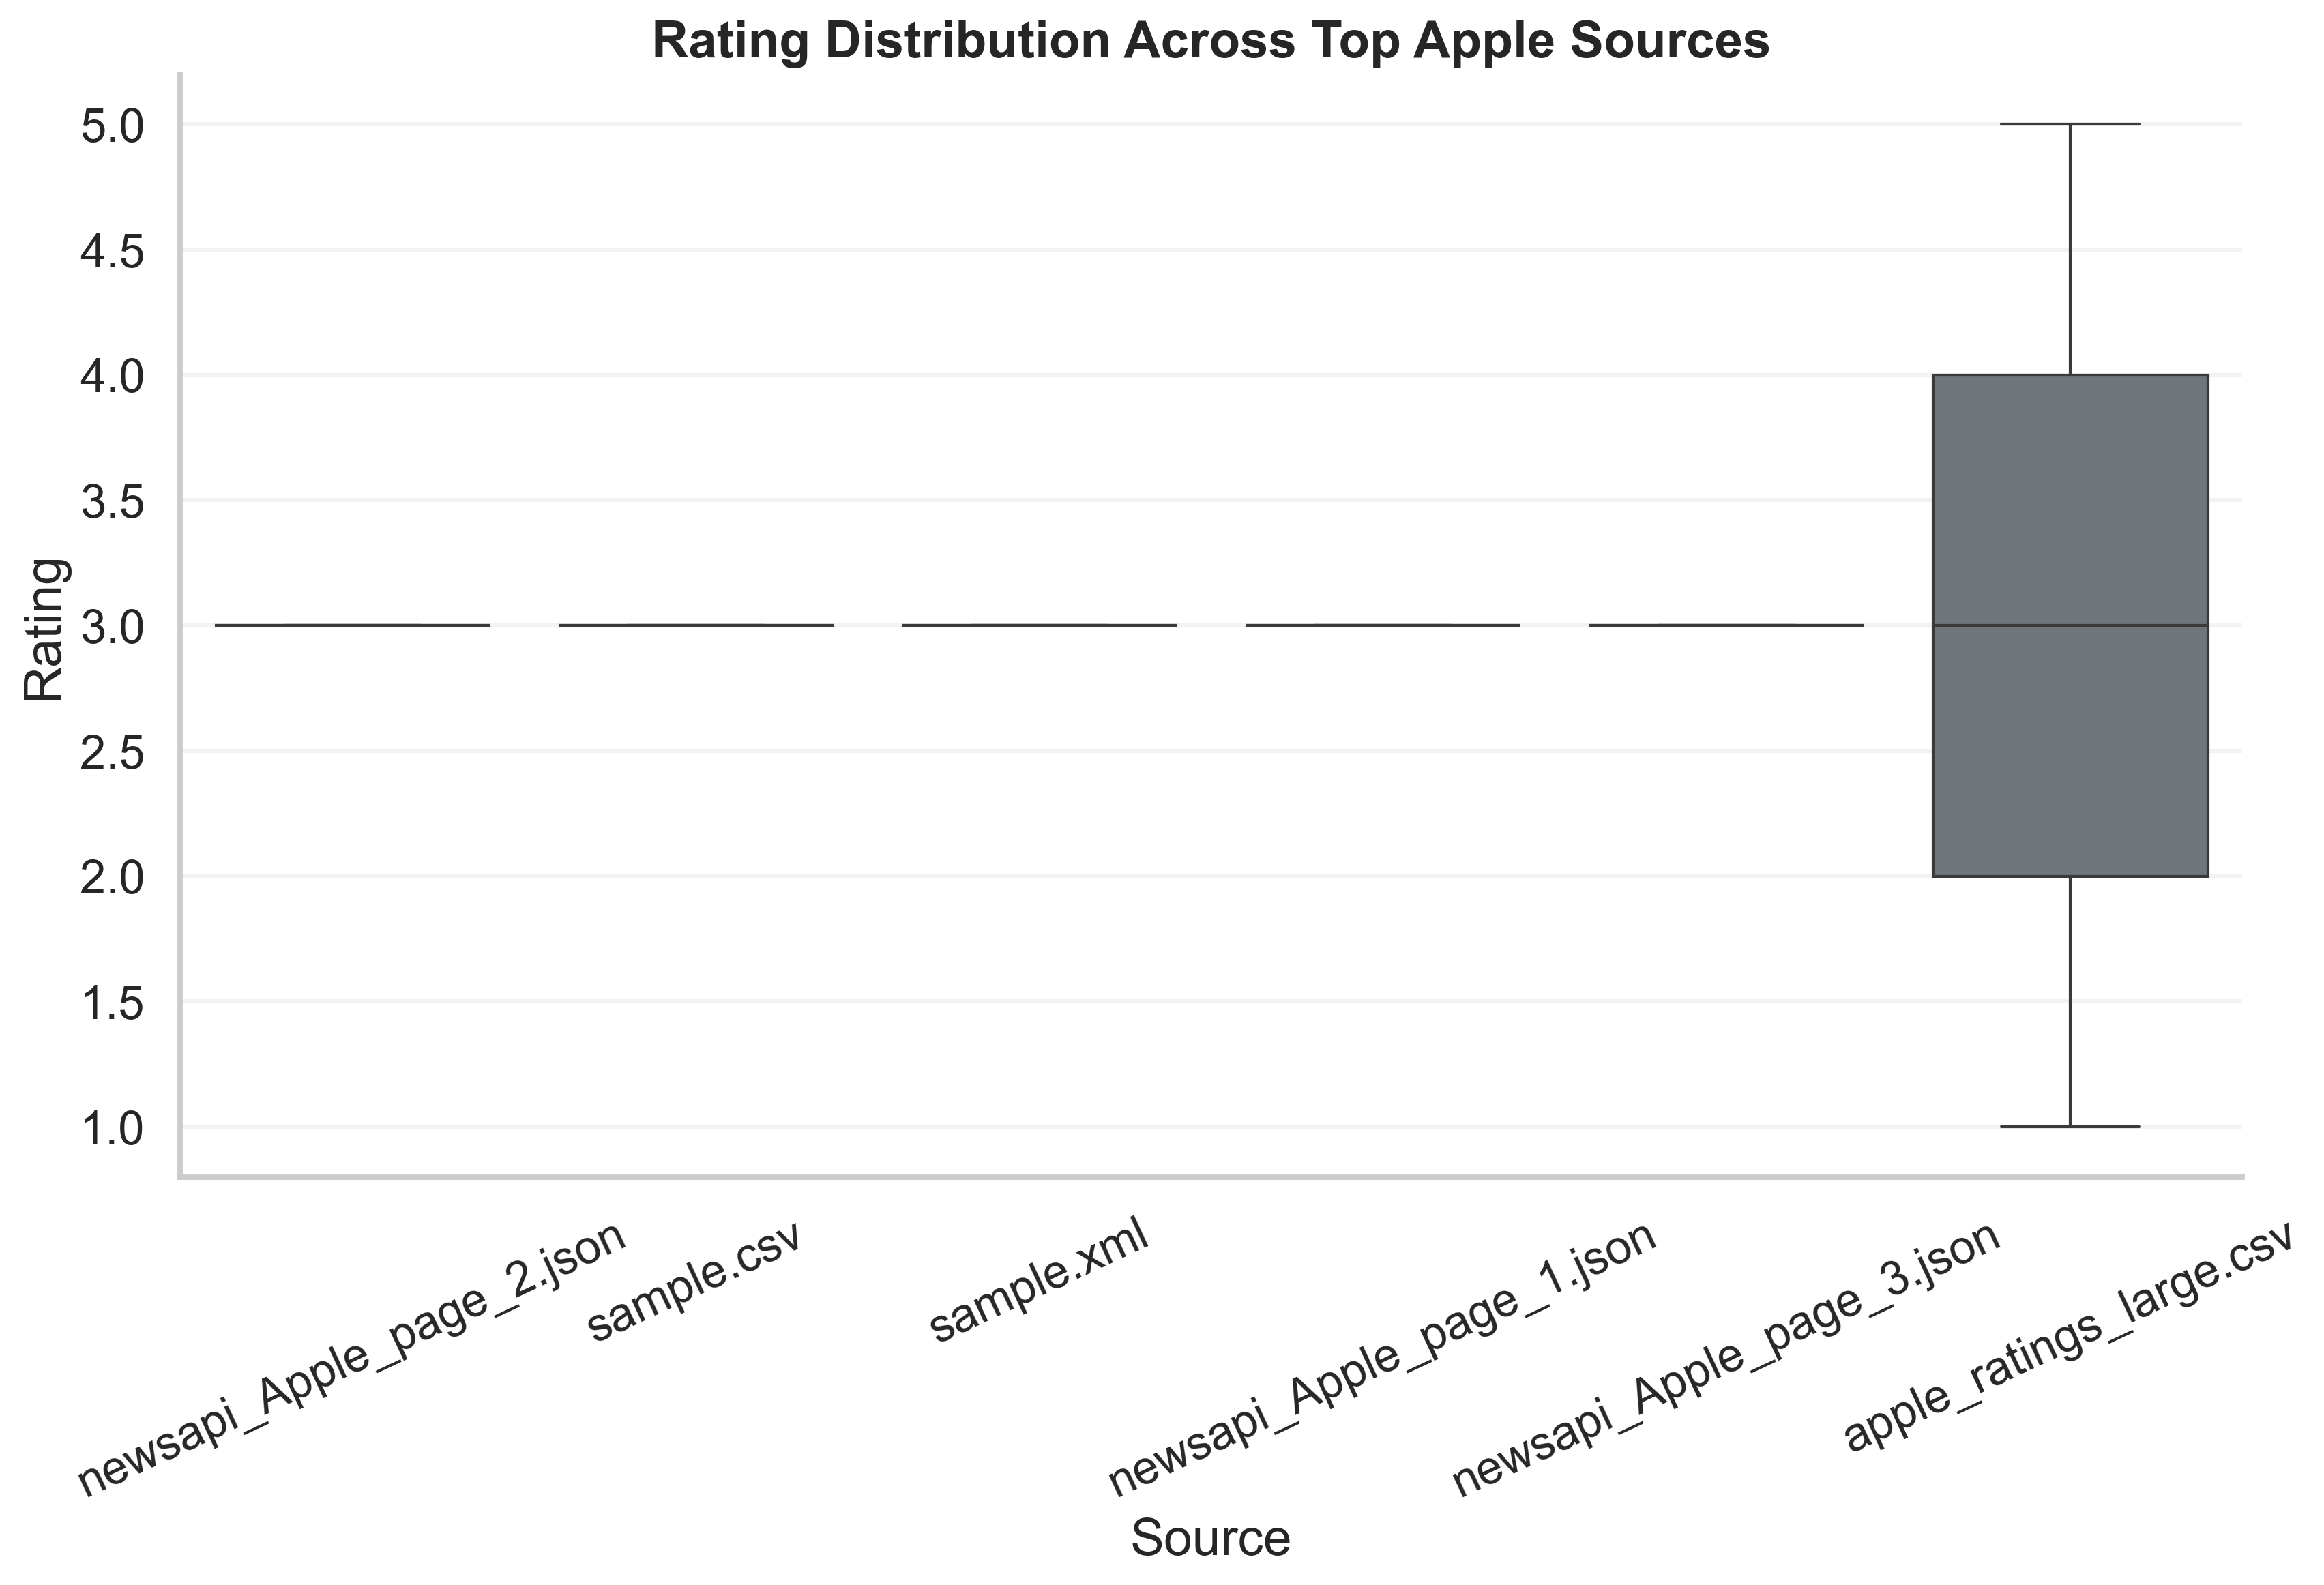

{'png': WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static/rating_by_source_boxplot.png'),
 'pdf': WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static/rating_by_source_boxplot.pdf')}

In [7]:
result = plot_rating_by_source_boxplot(df, STATIC_OUTPUT_DIR)
display(Image(filename=str(result["paths"]["png"])))
plt.close(result["figure"])
result["paths"]

### Explanation - Rating by Source Boxplot

This boxplot compares rating distributions across the busiest Apple sources. A boxplot is suitable because the question is not only which source has higher ratings, but how ratings vary, where the median lies, and whether there are outliers. That makes it better than a plain bar chart for comparing distributions rather than single summary values.

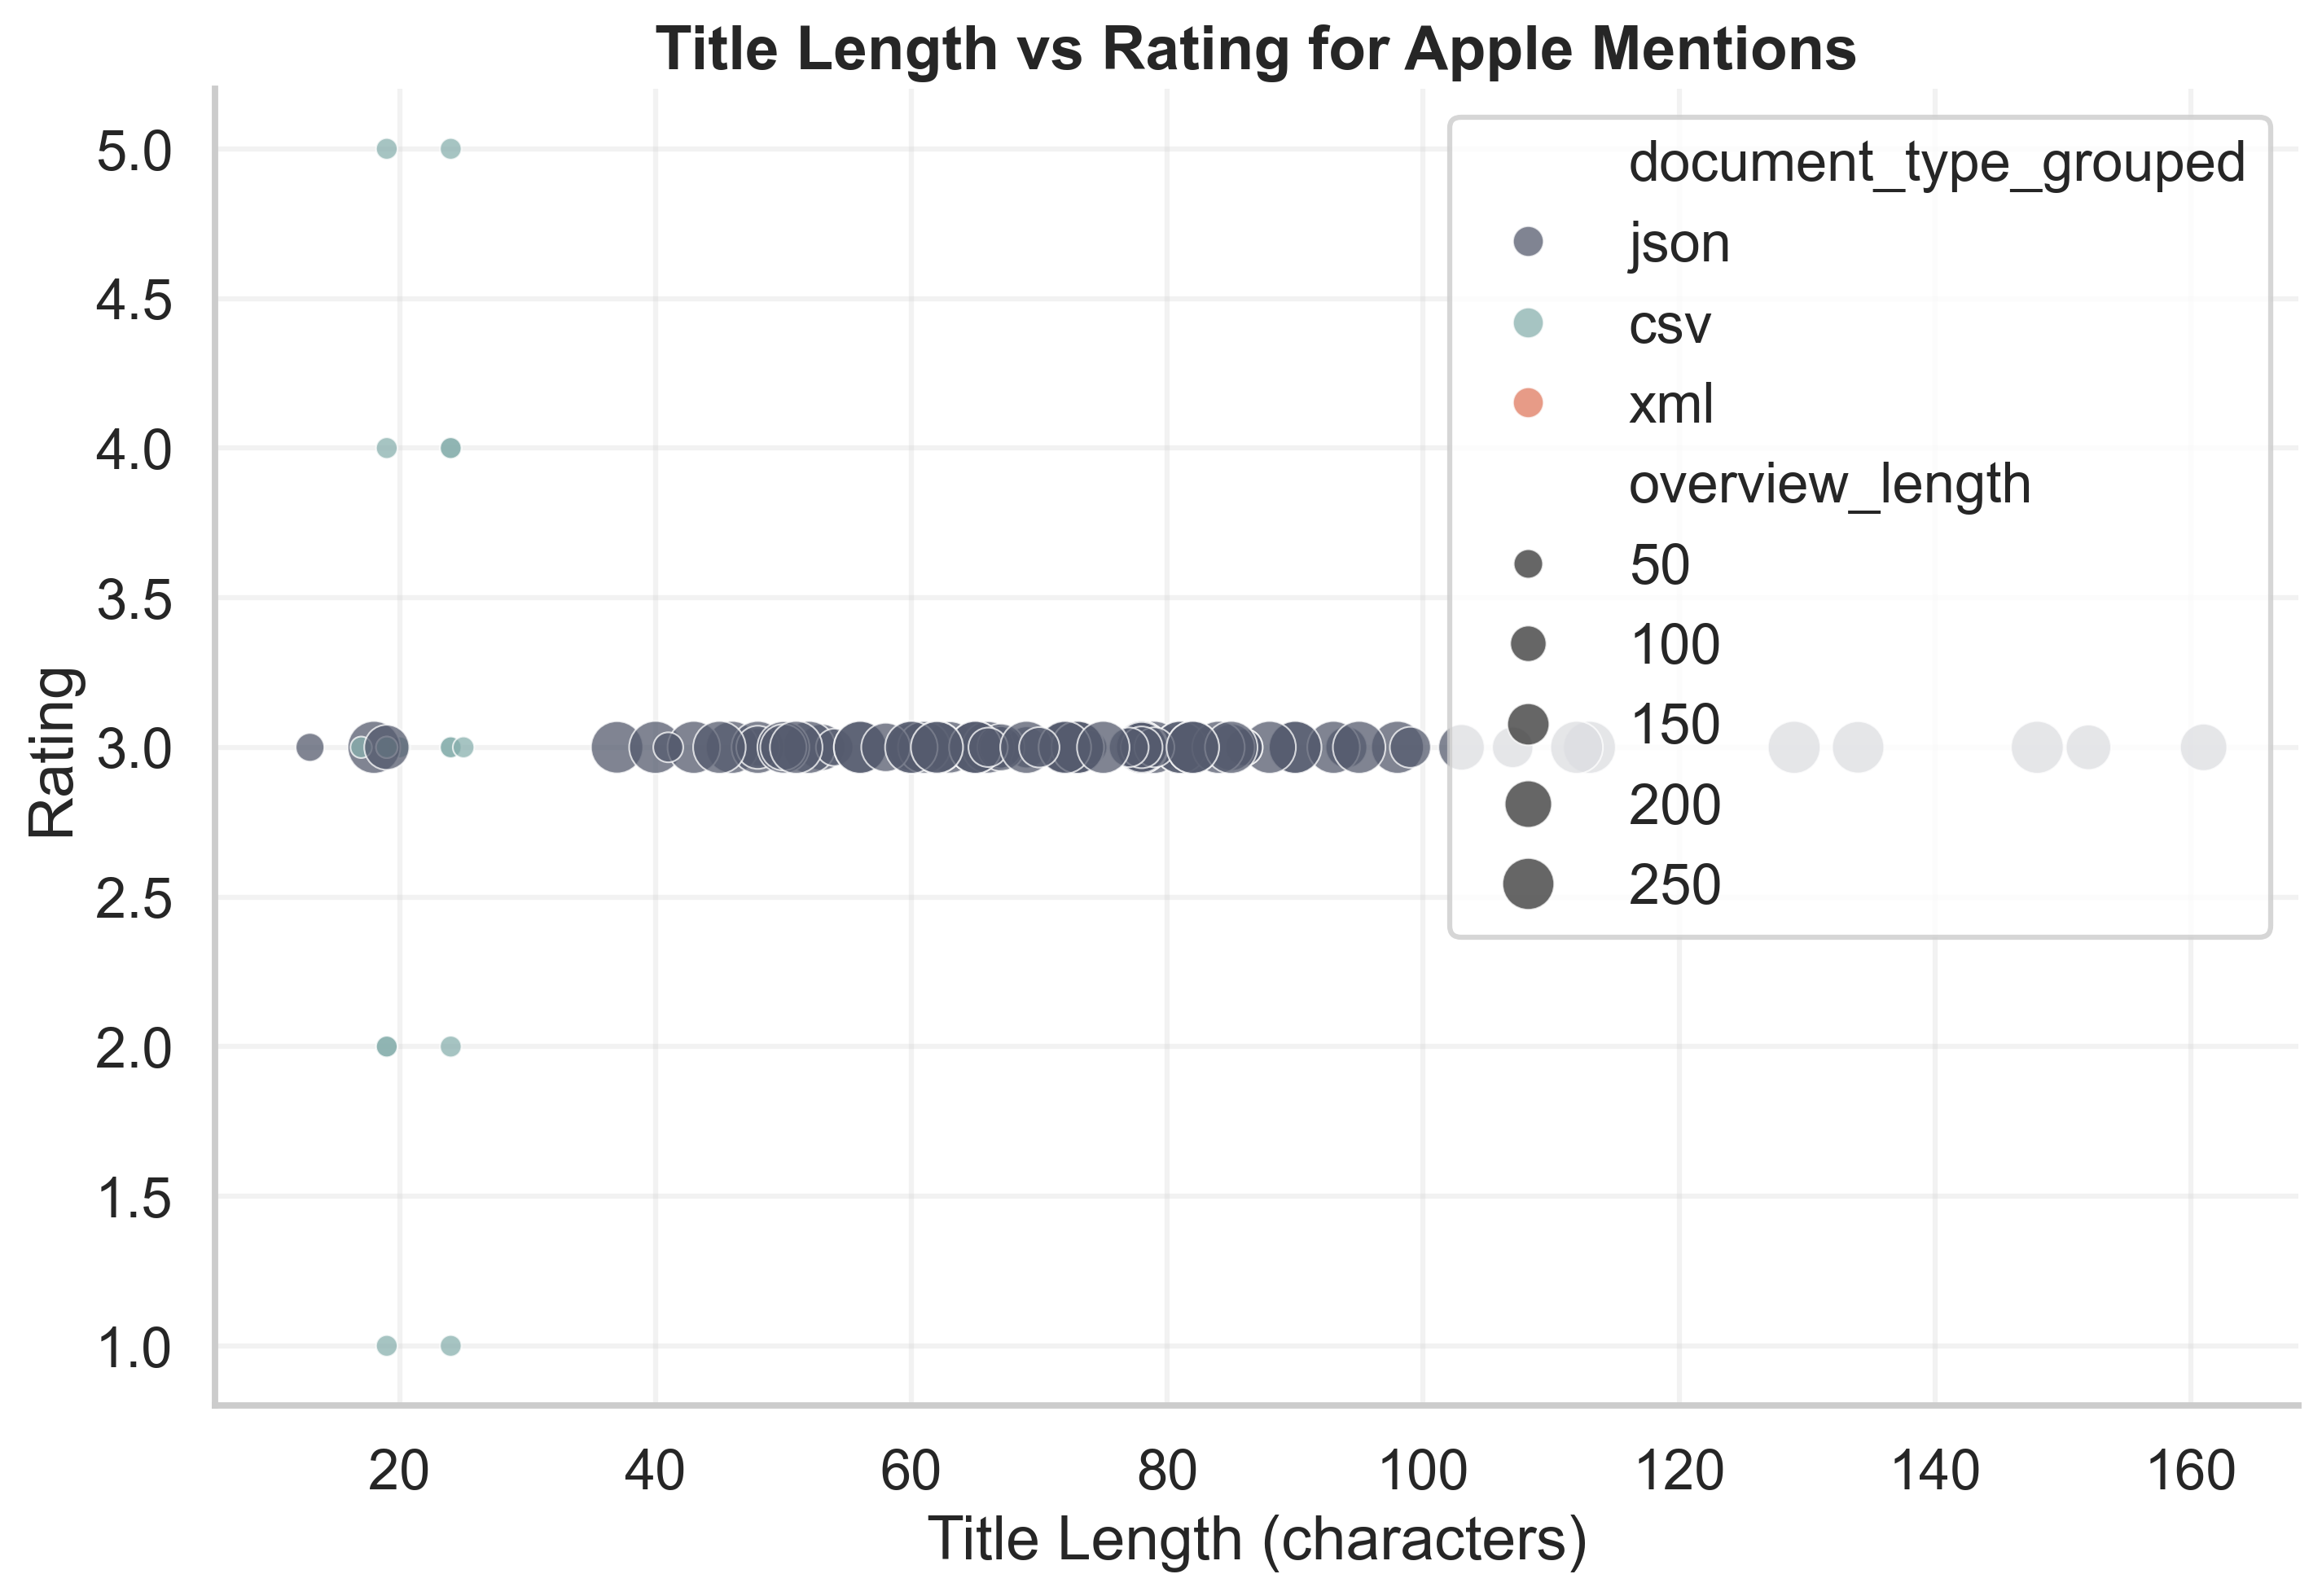

{'png': WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static/title_length_vs_rating.png'),
 'pdf': WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static/title_length_vs_rating.pdf')}

In [8]:
result = plot_title_length_vs_rating(df, STATIC_OUTPUT_DIR)
display(Image(filename=str(result["paths"]["png"])))
plt.close(result["figure"])
result["paths"]

### Explanation - Title Length vs Rating Scatter Plot

This chart explores whether longer Apple-related titles tend to be associated with different ratings. A scatter plot is the correct choice because it shows the relationship between two continuous variables, title length and rating. Colour is used for document type grouping and marker size adds a third variable, overview length, without replacing the core x-y relationship.

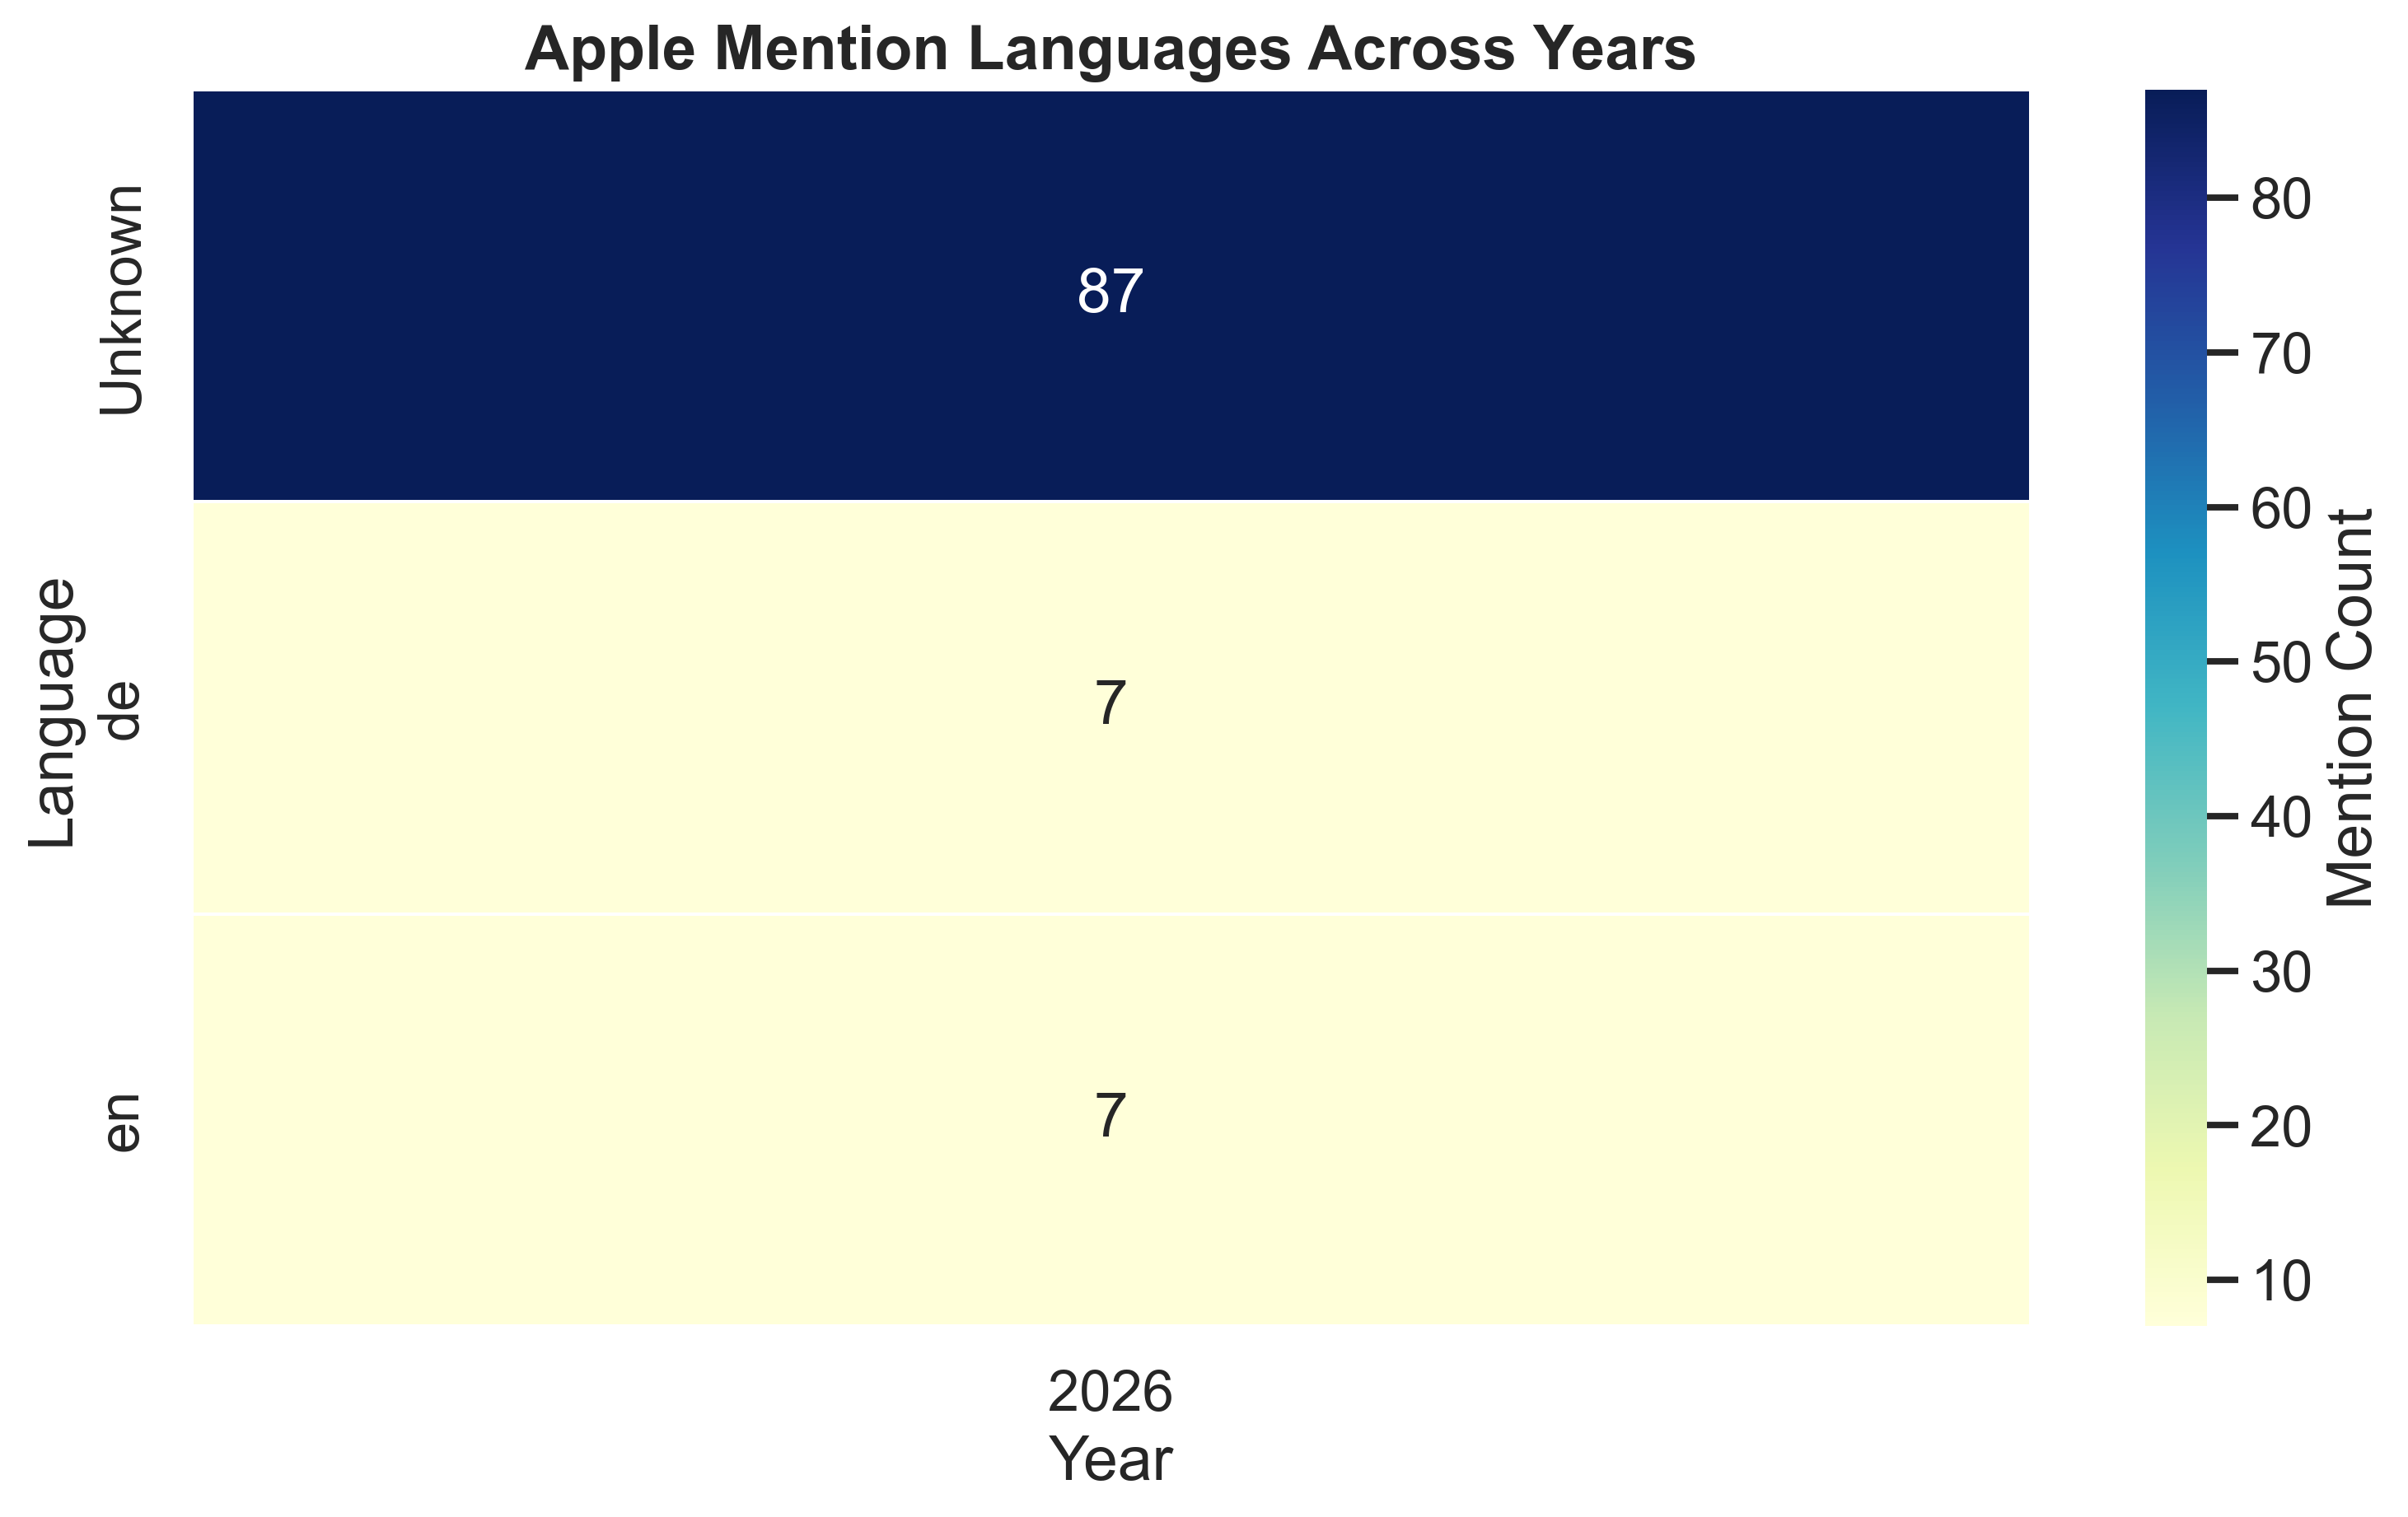

{'png': WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static/language_year_heatmap.png'),
 'pdf': WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static/language_year_heatmap.pdf')}

In [9]:
result = plot_language_year_heatmap(df, STATIC_OUTPUT_DIR)
display(Image(filename=str(result["paths"]["png"])))
plt.close(result["figure"])
result["paths"]

### Explanation - Language by Year Heatmap

This heatmap summarizes how Apple mentions are distributed across languages and years. A heatmap is a strong choice for a two-dimensional frequency table because colour intensity reveals concentration patterns immediately. The annotation values preserve exactness, so the figure balances compactness with interpretability.

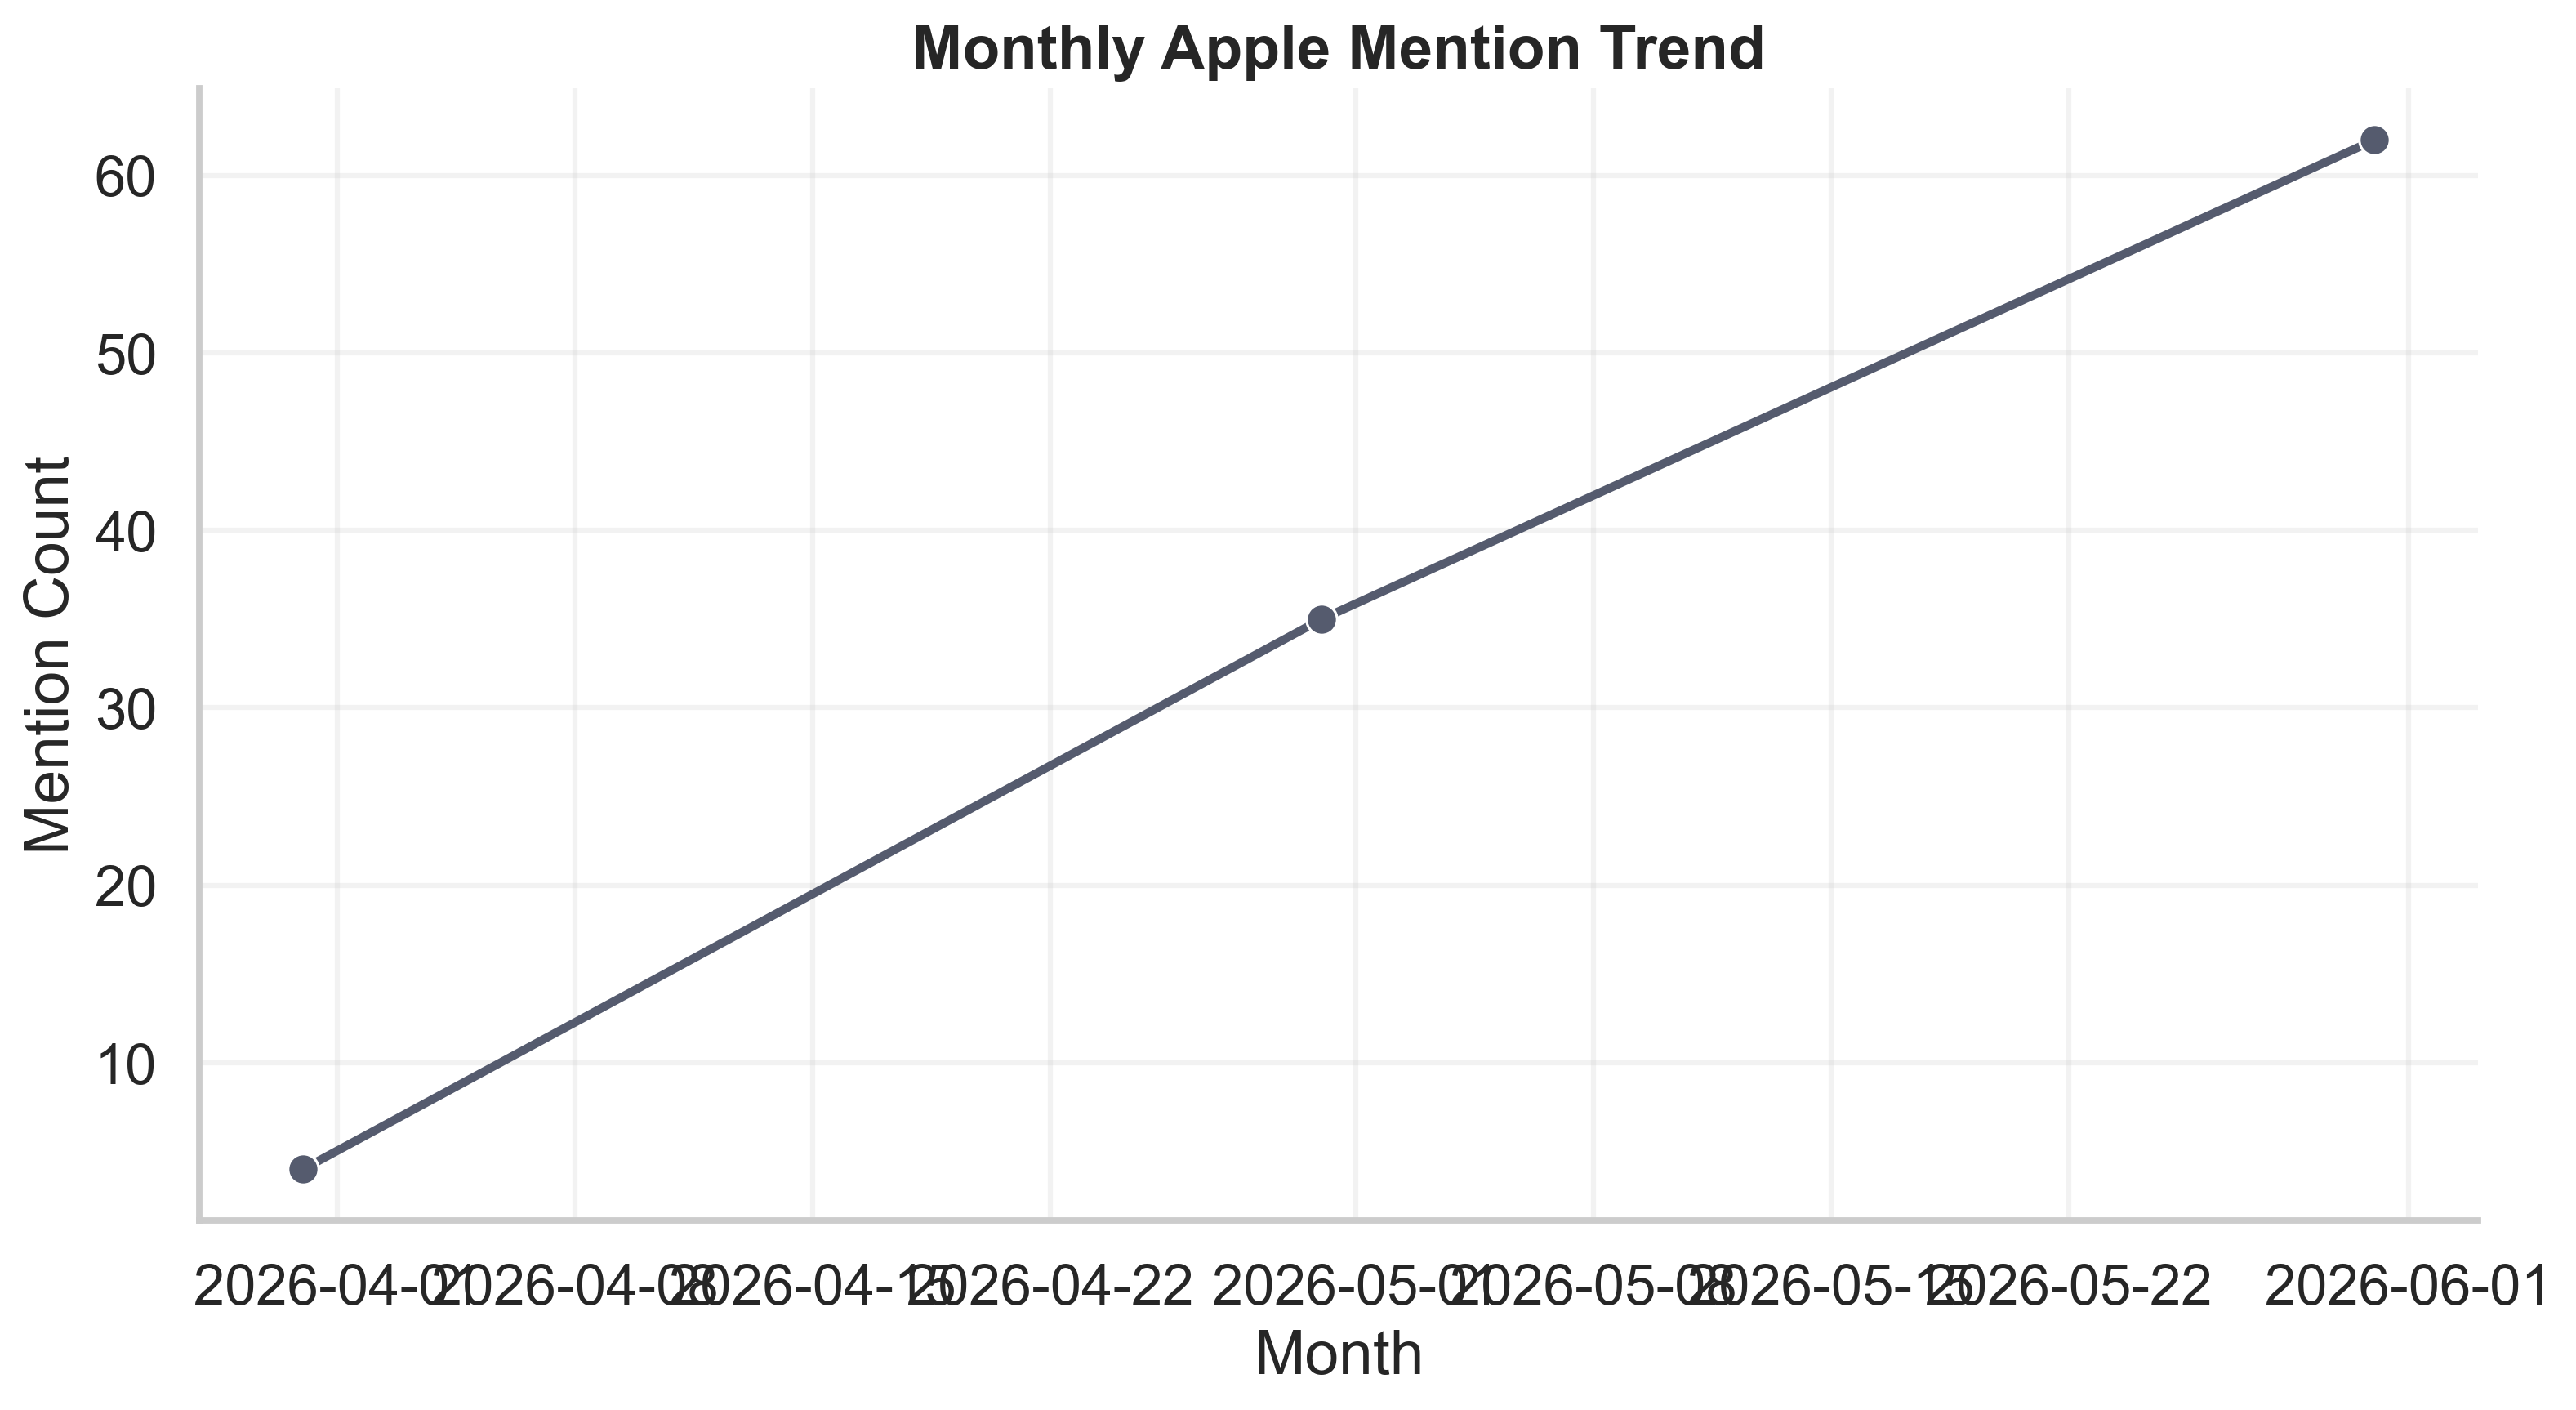

{'png': WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static/monthly_mentions_line.png'),
 'pdf': WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static/monthly_mentions_line.pdf')}

In [10]:
result = plot_monthly_mentions_line(df, STATIC_OUTPUT_DIR)
display(Image(filename=str(result["paths"]["png"])))
plt.close(result["figure"])
result["paths"]

### Explanation - Monthly Mentions Line Chart

This chart shows how Apple mention volume changes month by month. A line chart is appropriate because time is ordered and the main question is trend over sequence rather than isolated category comparison. The connected points emphasize continuity and make spikes or quiet periods easy to detect.

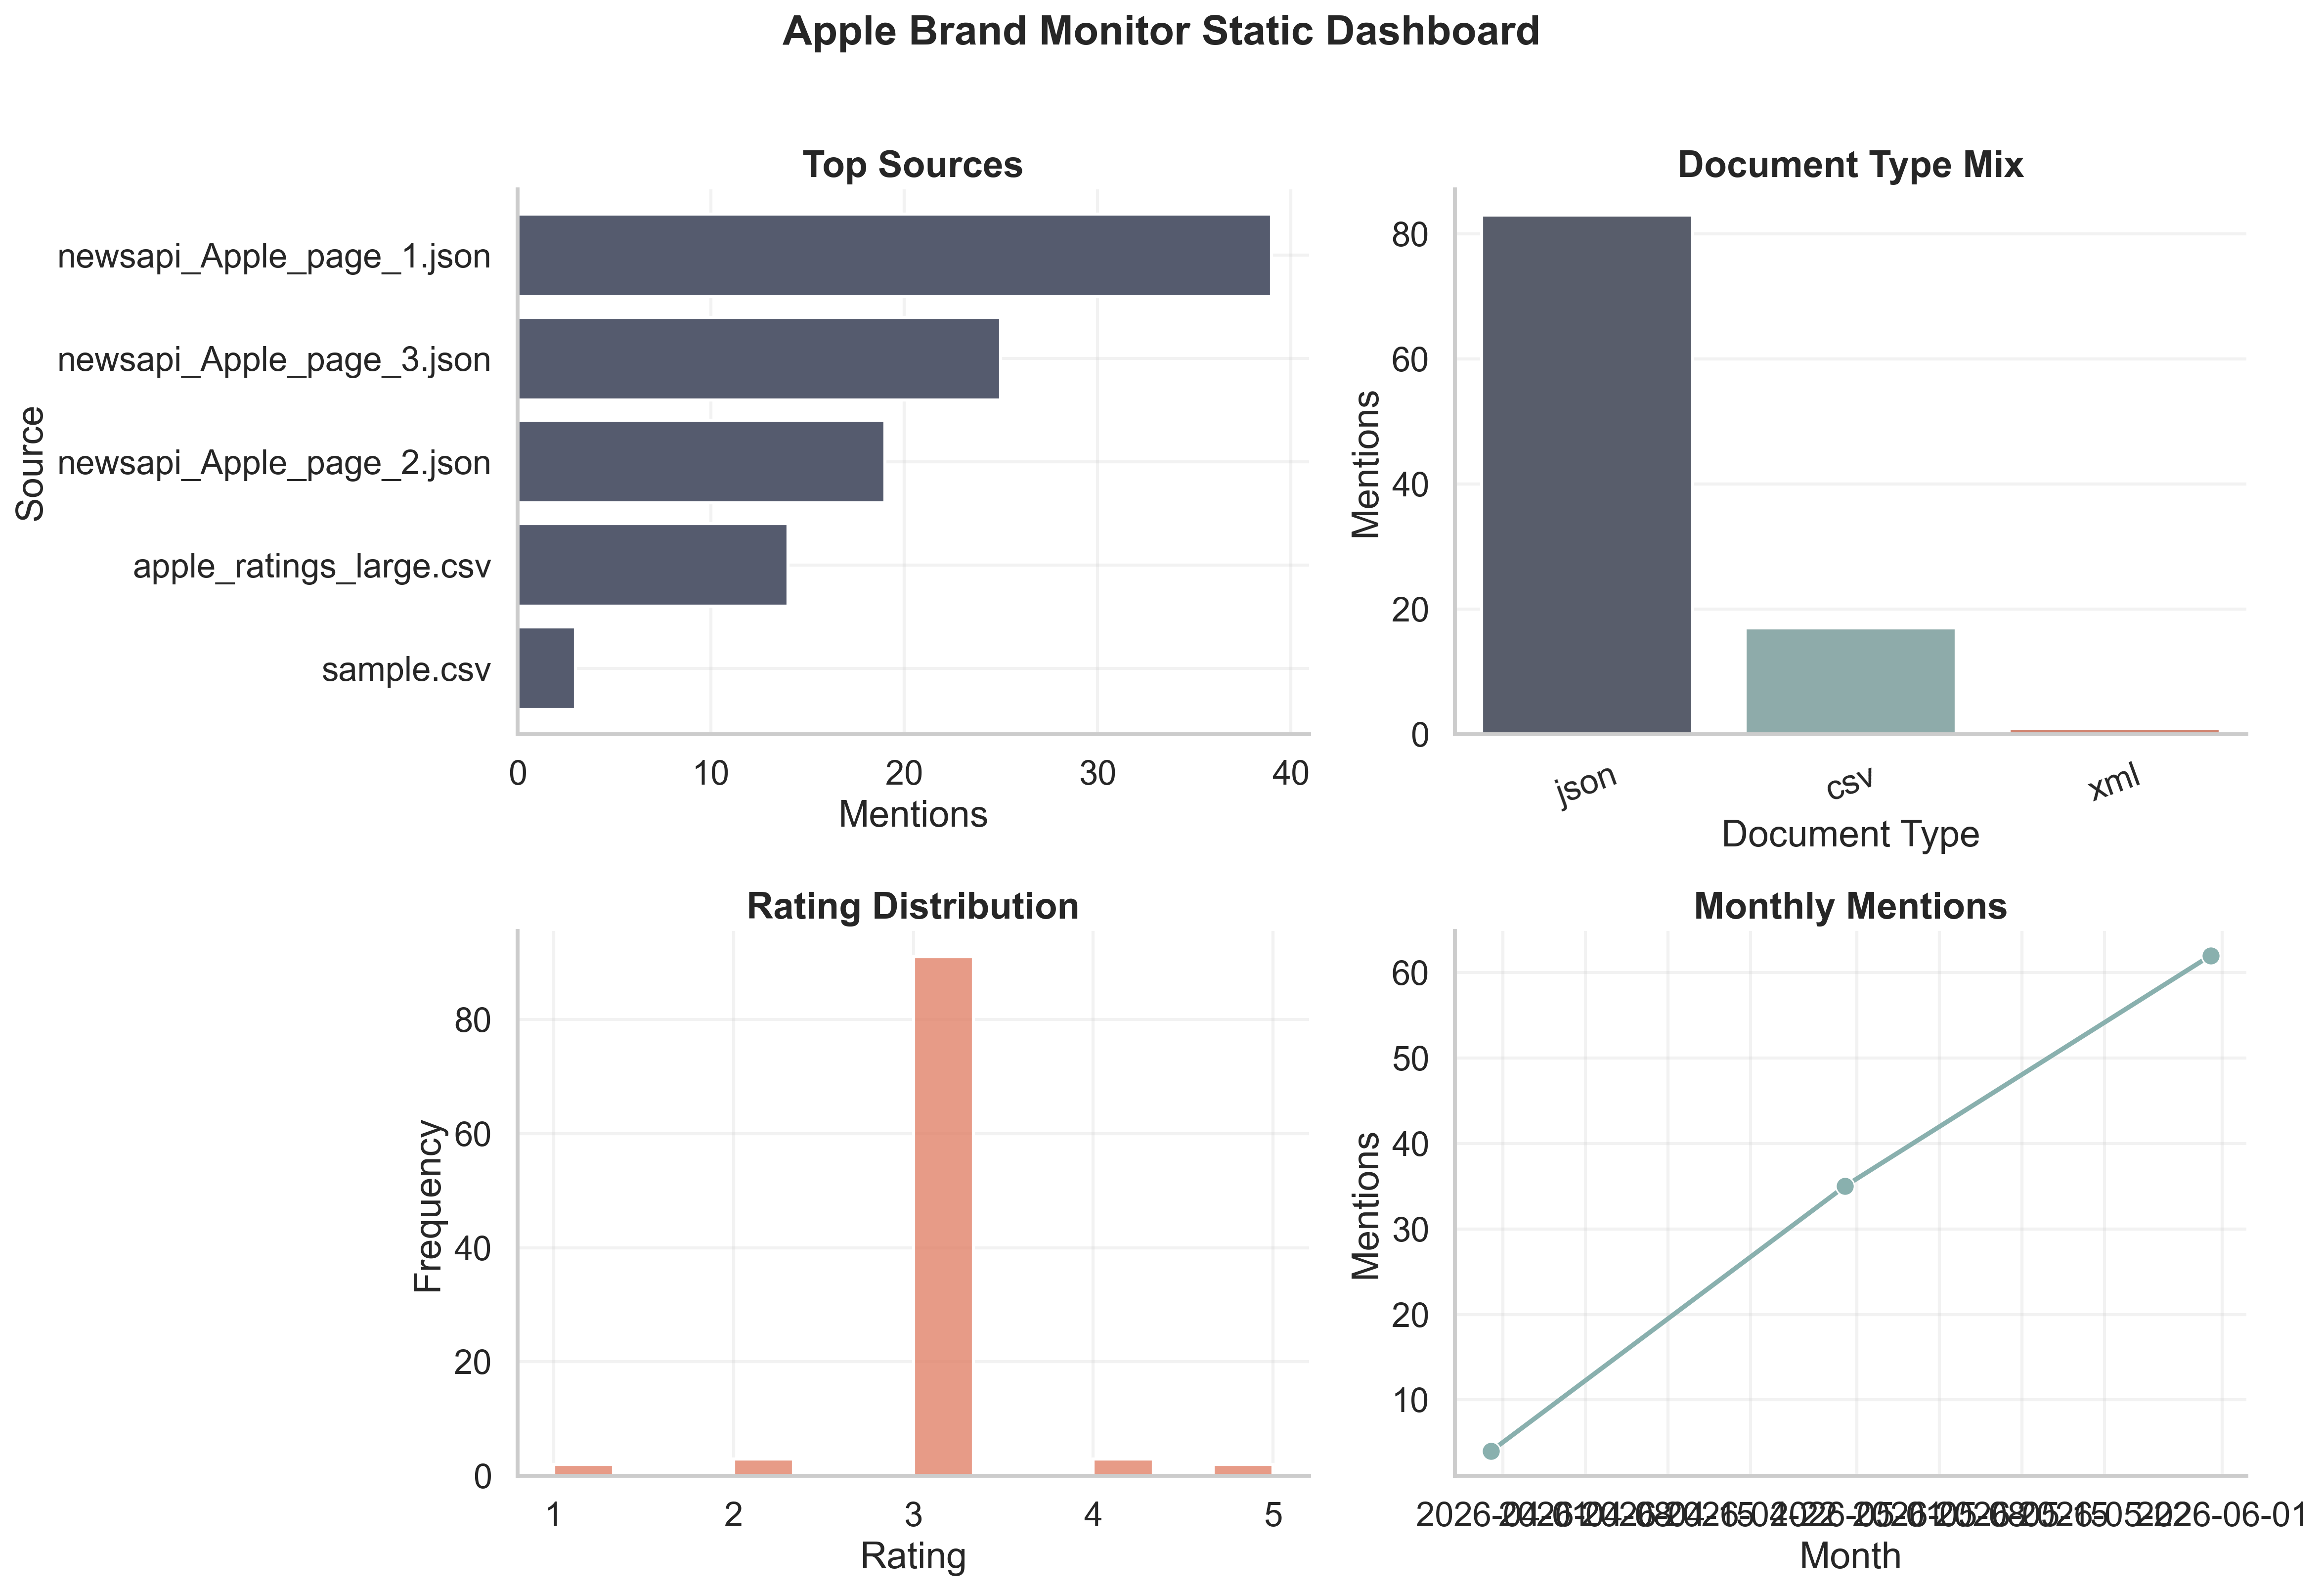

{'png': WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static/dashboard_subplots.png'),
 'pdf': WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static/dashboard_subplots.pdf')}

In [11]:
result = plot_dashboard_subplots(df, STATIC_OUTPUT_DIR)
display(Image(filename=str(result["paths"]["png"])))
plt.close(result["figure"])
result["paths"]

### Explanation - Static Dashboard

This four-panel dashboard combines the most useful Apple monitoring views on one canvas: top sources, document-type mix, rating distribution, and monthly mentions. A multi-panel layout is appropriate when the goal is executive summary rather than a single narrow question. Each panel keeps a clear encoding, and the combined design avoids chartjunk by using simple axes, restrained colour, and shared visual style.

## Interactive Charts

In [12]:
result = interactive_top_sources(df, INTERACTIVE_OUTPUT_DIR)
result["figure"].show()
result["path"]

WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/interactive/interactive_top_sources.html')

### Explanation - Interactive Top Sources

This interactive chart answers the same source-comparison question as the static bar chart, but adds hover details about unique document types and unique languages. Interactivity is valuable here because the reader can inspect each source without cluttering the figure with extra printed labels. This follows Tufte's principle by moving detail-on-demand into the tooltip instead of crowding the canvas.

In [13]:
result = interactive_mentions_timeline(df, INTERACTIVE_OUTPUT_DIR)
result["figure"].show()
result["path"]

WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/interactive/interactive_mentions_timeline.html')

### Explanation - Interactive Mention Timeline

This chart tracks monthly Apple mention volume while exposing average rating and unique-source counts in the tooltip. A line chart remains the correct base encoding because this is a time-trend question. Plotly adds zooming and hover inspection, which is especially useful for investigating particular periods without changing the chart type.

In [14]:
result = interactive_rating_by_document_type(df, INTERACTIVE_OUTPUT_DIR)
result["figure"].show()
result["path"]

WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/interactive/interactive_rating_by_document_type.html')

### Explanation - Interactive Rating by Document Type

This chart compares rating distributions across document types, while individual points reveal title, source, and language on hover. A box plot is still the correct statistical view because the task is distribution comparison. Interactivity complements that by letting the reader inspect specific observations behind the summary structure.

In [15]:
result = interactive_title_length_scatter(df, INTERACTIVE_OUTPUT_DIR)
result["figure"].show()
result["path"]

WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/interactive/interactive_title_length_scatter.html')

### Explanation - Interactive Title Length Scatter

This scatter plot is designed for relationship analysis between title length and rating, with extra context in hover data and marker size. Scatter plots are appropriate for continuous-variable relationships, and the interactive version is useful because dense point clouds are much easier to inspect with hover, zoom, and legend filtering.

In [16]:
result = interactive_multi_layout_dashboard(df, INTERACTIVE_OUTPUT_DIR)
result["figure"].show()
result["path"]

WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/interactive/interactive_multi_layout_dashboard.html')

### Explanation - Interactive Dashboard

This dashboard combines source concentration, document-type composition, monthly trend, and language coverage in one interactive view. A dashboard layout is appropriate when several related monitoring questions need to be explored together. Plotly Graph Objects and subplots were chosen because they allow richer coordinated layout control than a single Plotly Express chart.

## Automated Generator

INFO: Visualization dataset loaded | path=C:\Users\topic\OneDrive\Desktop\PROJECTS\Projekat za unstructured data\social_media_brand_monitor\data\processed\cleaned\cleaned_data.csv | rows=101 | columns=20


INFO: Generating static chart | function=plot_top_sources_barh | output_dir=C:\Users\topic\OneDrive\Desktop\PROJECTS\Projekat za unstructured data\social_media_brand_monitor\outputs\visualizations\static


INFO: Generating static chart | function=plot_mentions_and_rating_by_year | output_dir=C:\Users\topic\OneDrive\Desktop\PROJECTS\Projekat za unstructured data\social_media_brand_monitor\outputs\visualizations\static


INFO: Generating static chart | function=plot_mentions_by_document_type | output_dir=C:\Users\topic\OneDrive\Desktop\PROJECTS\Projekat za unstructured data\social_media_brand_monitor\outputs\visualizations\static


INFO: Generating static chart | function=plot_rating_distribution | output_dir=C:\Users\topic\OneDrive\Desktop\PROJECTS\Projekat za unstructured data\social_media_brand_monitor\outputs\visualizations\static


...

INFO: Generating interactive chart | function=interactive_title_length_scatter | output_dir=C:\Users\topic\OneDrive\Desktop\PROJECTS\Projekat za unstructured data\social_media_brand_monitor\outputs\visualizations\interactive


INFO: Generating interactive chart | function=interactive_multi_layout_dashboard | output_dir=C:\Users\topic\OneDrive\Desktop\PROJECTS\Projekat za unstructured data\social_media_brand_monitor\outputs\visualizations\interactive


INFO: Visualization generation complete | static=9 | interactive=5 | output_root=C:\Users\topic\OneDrive\Desktop\PROJECTS\Projekat za unstructured data\social_media_brand_monitor\outputs\visualizations


Static charts generated: 9
Interactive charts generated: 5


(WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/static'),
 WindowsPath('C:/Users/topic/OneDrive/Desktop/PROJECTS/Projekat za unstructured data/social_media_brand_monitor/outputs/visualizations/interactive'))

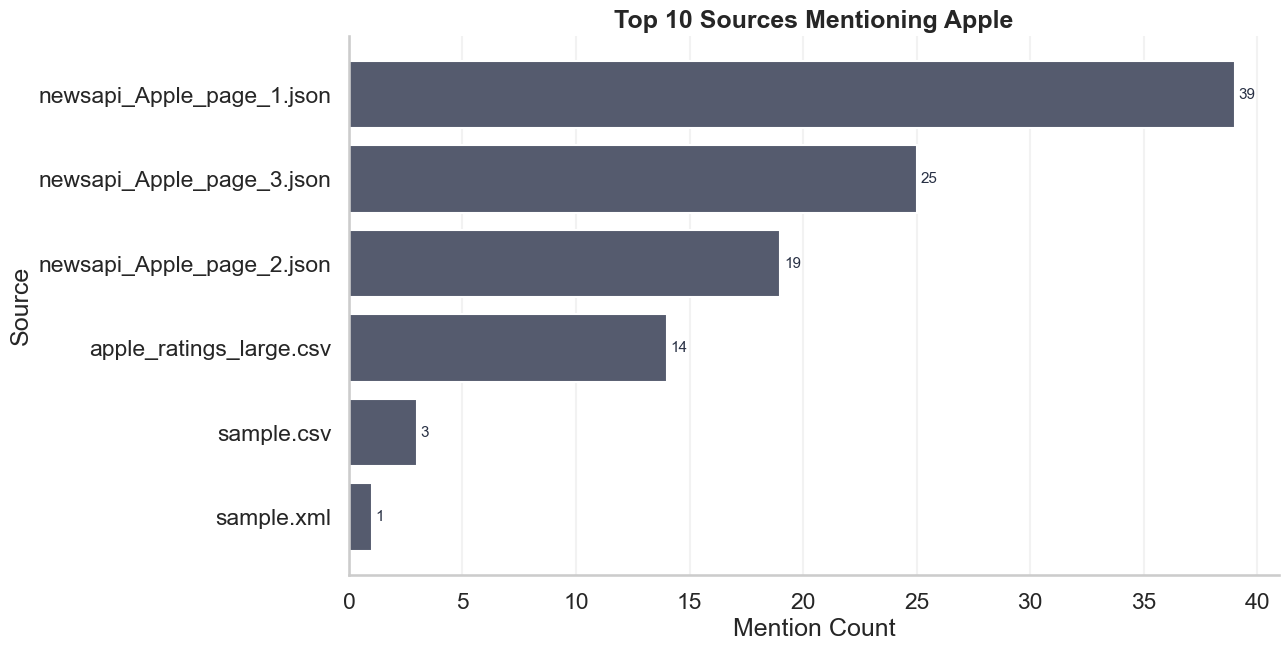

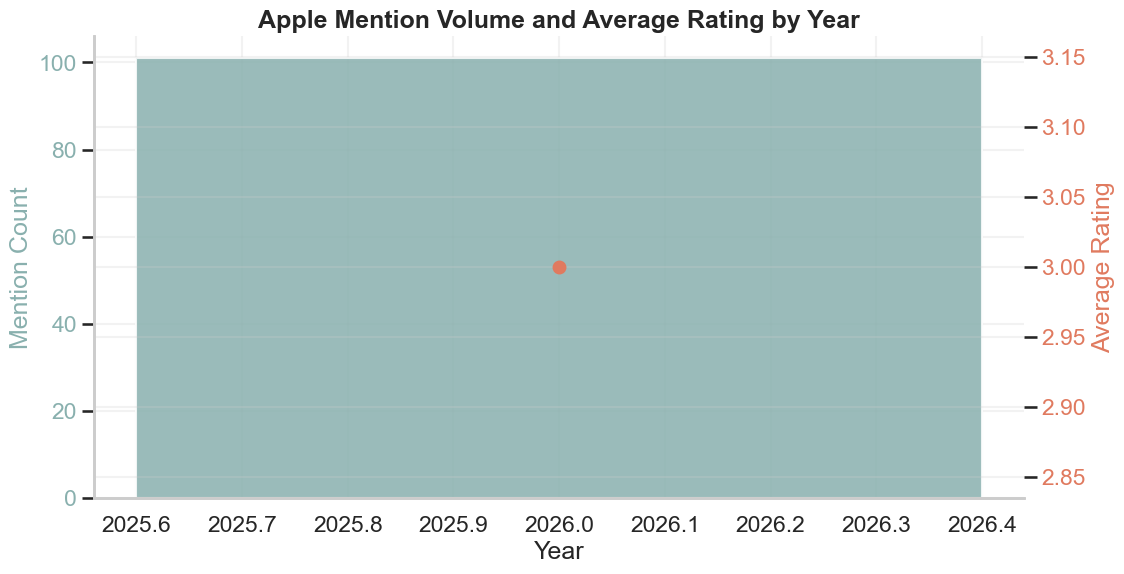

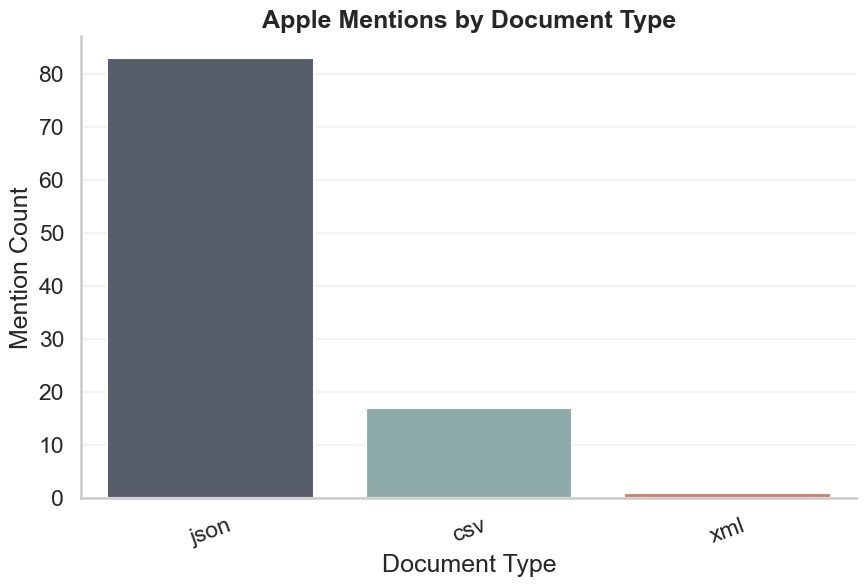

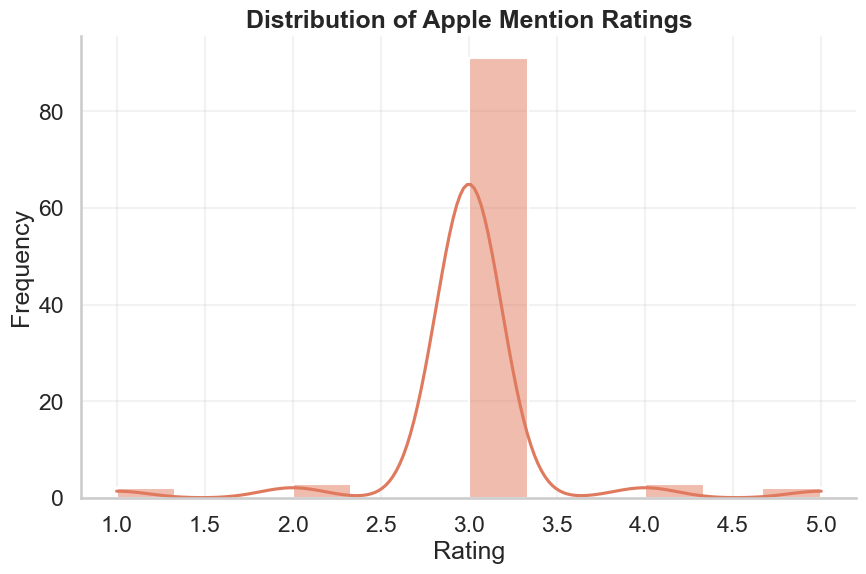

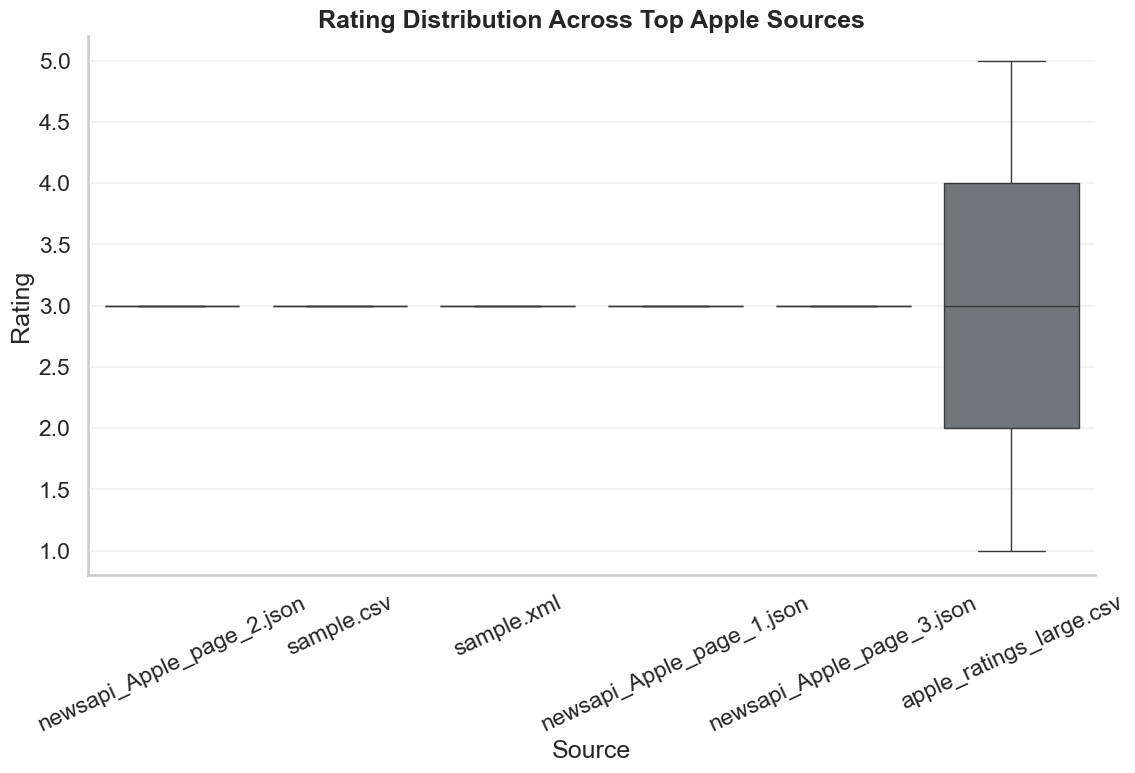

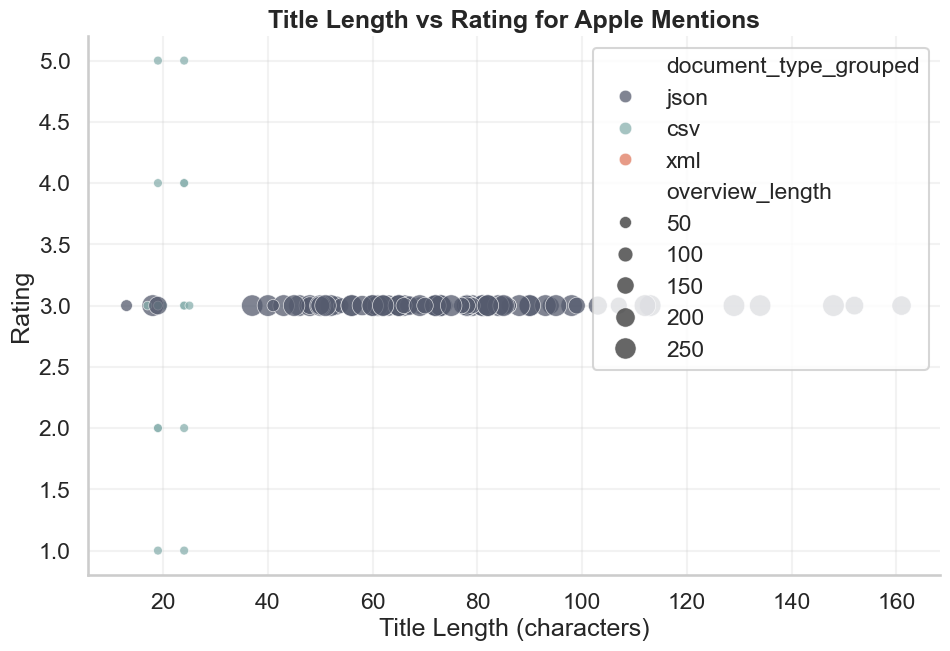

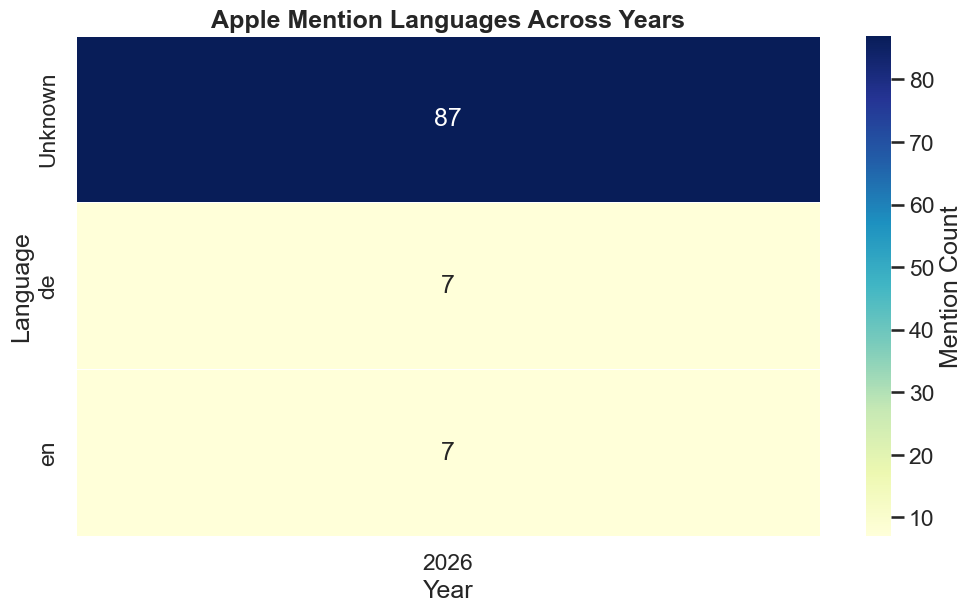

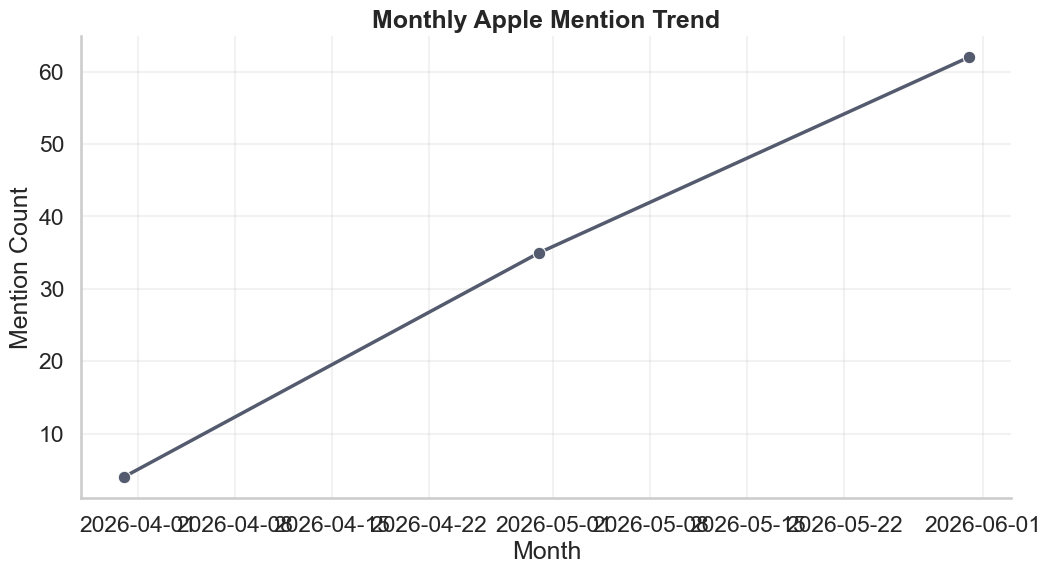

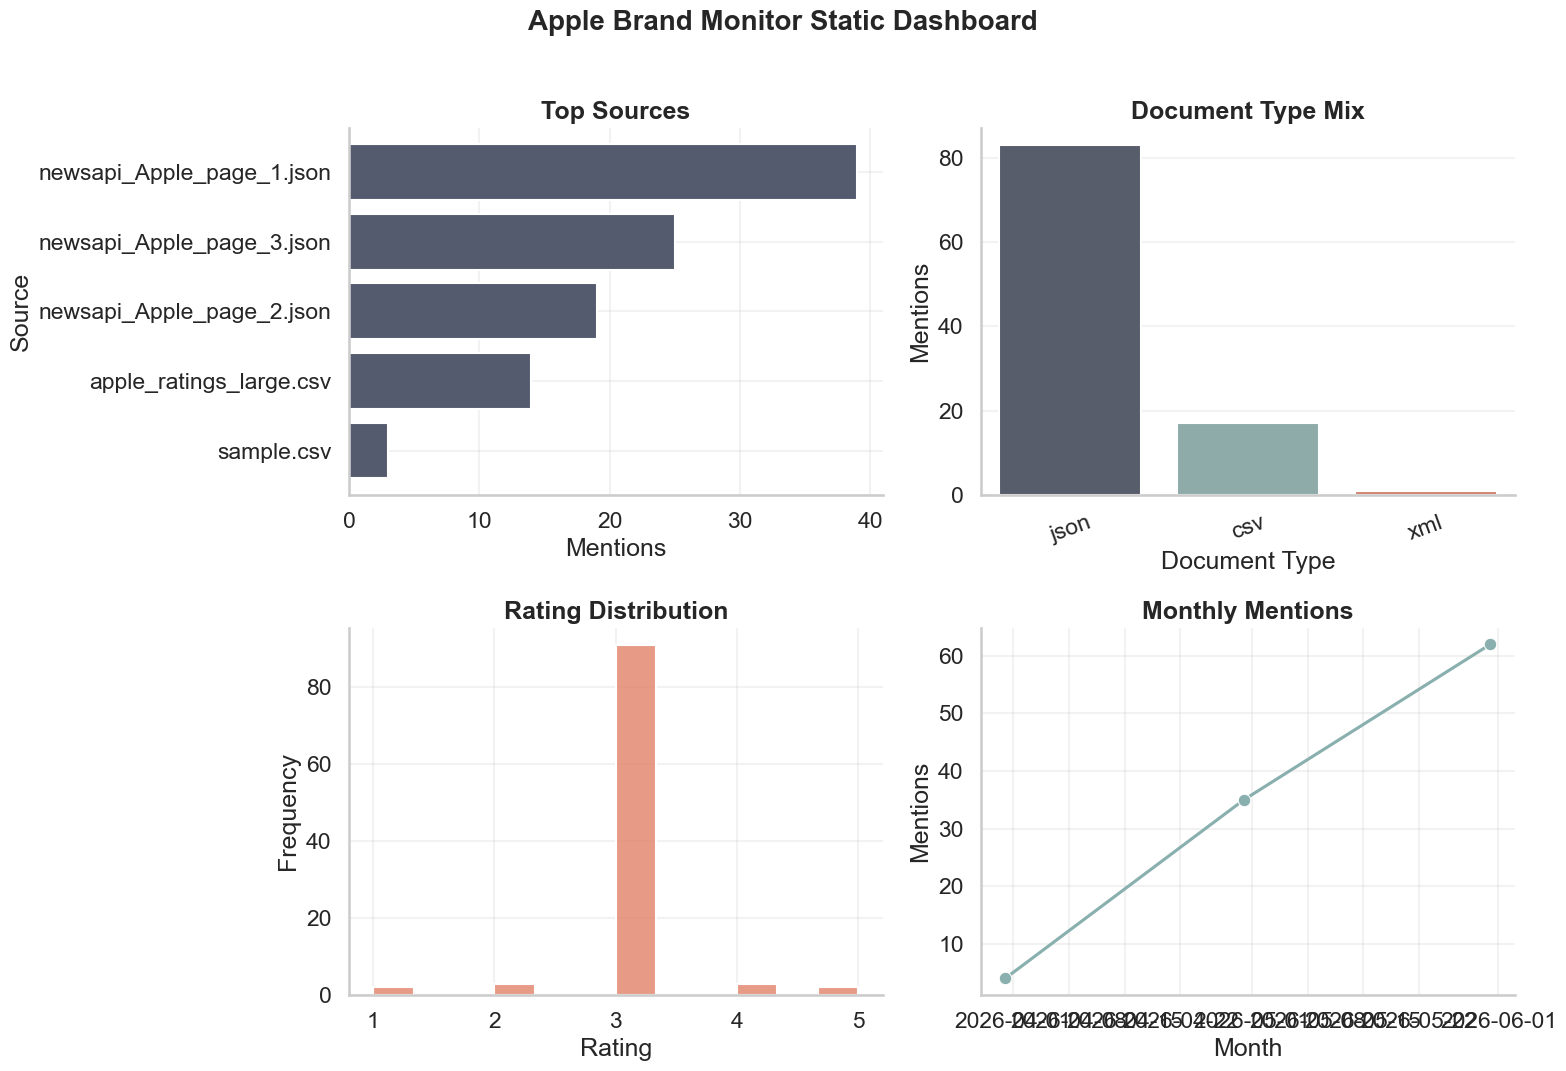

In [17]:
generation_results = generate_all_visualizations(data_path=DATA_PATH, output_root=PROJECT_ROOT / "outputs" / "visualizations")
print(f"Static charts generated: {len(generation_results['static_results'])}")
print(f"Interactive charts generated: {len(generation_results['interactive_results'])}")
generation_results["static_output_dir"], generation_results["interactive_output_dir"]

The automated generator is useful because it turns the visualization workflow into a repeatable pipeline step. Instead of manually running each function every time the data changes, the whole static and interactive output set can be regenerated from one command.

## Visualization Choice Documentation

The chart choices in this notebook follow standard statistical matching and Tufte's principles of graphical excellence.

- Bar charts were used for comparing discrete categories such as sources and document types because aligned lengths on a common scale make differences easy to judge.
- The time-series line chart was used for monthly mentions because trends across ordered time are better seen through connected values than separated bars.
- The dual-axis combination chart was used only where two yearly signals shared the same temporal axis but had different scales.
- Histograms were used for rating distribution because they reveal concentration and spread of a continuous variable.
- Boxplots were used for comparing rating distributions across groups because medians, quartiles, and outliers matter more than just group averages.
- The scatter plot was used for title length versus rating because the goal was to examine a relationship between two continuous variables, with colour and marker size used as supporting encodings.
- The heatmap was used for language-by-year counts because it compresses a two-dimensional table into a compact, readable pattern view.
- The dashboards combine several high-value views into one summary surface for reporting and exploratory use.

Across the notebook, the design aims to avoid chartjunk, use restrained colour, keep labels close to the data, and let the data itself carry most of the visual weight.

## Conclusion

The Lab 12 visualization module is fully adapted to the Apple social media brand-monitor theme. The notebook demonstrates every static and interactive chart, explains why each chart type was chosen, and shows how the entire visualization set can be regenerated automatically from the cleaned dataset.